# utility functions

In [32]:
import wandb
import pandas as pd
from tqdm import tqdm
import numpy as np

def get_dataframe_from_records(records, add_custom_columns=None):
    """Convert records to a DataFrame."""
    
    # Create DataFrame
    df = pd.DataFrame(records)

    if add_custom_columns:
        df = add_custom_columns(df)

    # Group by group and calculate mean and std
    agg_df = df.groupby("group").agg(['mean', 'std'])
    # chech that for each group there are 5 entries

    agg_df_check = df.groupby("group").count()
    if (agg_df_check < 5).any().any():
        print("Warning: Some groups have fewer than 5 entries.")

    # format to mean /pm std
    # Format as 'mean ± std' rounded to 3 decimals
    formatted_df = agg_df.copy()
    for metric in df.columns[1:]:  # Skip 'group' column
        mean_col = (metric, 'mean')
        std_col = (metric, 'std')
        formatted_col_name = f"{metric} (mean ± std)"
        
        #set min value to row[std_col] to 0.001

        formatted_df[formatted_col_name] = agg_df.apply(
            lambda row: f"{row[mean_col]:.3f} ± {row[std_col]:.3f}", axis=1
        )
    # Optional: flatten the column names
    # agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    # remove original colums
    formatted_df = formatted_df.drop(columns=[(col, 'mean') for col in df.columns[1:]] + [(col, 'std') for col in df.columns[1:]])
    return formatted_df

def only_best(run):
    return run.group is not None and run.group.startswith("best_")

def get_records(project, metrics=[], history=[], config=[], get_memory=False, pattern=only_best, verbose=False, regex=None):
    # Authenticate (you must be logged in via wandb.login())
    api = wandb.Api()

    # Replace with your entity/project
    entity = "ecg_ml"

    # Fetch all runs
    if not regex:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished"}) #, "group":{"$regex": "^best_"}})
    else:
        runs = api.runs(f"{entity}/{project}", filters={"state": "finished", "group": {"$regex": regex}})

    # Collect relevant info
    records = []
    for run in tqdm(runs):
        if run.state != "finished":
            continue

        # add only if group name starts with best_
        if not pattern(run):
            continue

        # Get the group name
        group = run.group or "ungrouped"

        record = {
            "group": group
        }

        # Extract your test metrics — replace with your actual metric names
        if verbose:
            print(f"Processing run {run.id} in group '{group}'")
            # print metrics of the run
            print("Metrics:", [key for key in run.summary.keys() if key.startswith("test_")])

        for metric in metrics:
            if metric not in run.summary:
                print(f"Warning: Metric '{metric}' not found in run {run.id}.")
                continue
            record[metric] = run.summary.get(metric)

        for metric, mode in history:
            if metric not in run.history(keys=[metric]).columns:
                print(f"Warning: Metric '{metric}' not found in history of run {run.id}.")
                continue
            if mode == 'max':
                record[metric] = run.history(keys=[metric])[metric].dropna().max()
            elif mode == 'min':
                record[metric] = run.history(keys=[metric])[metric].dropna().min()
            else:
                record[metric] = run.history(keys=[metric])[metric].dropna().values[-1]

        for c in config:
            if c not in run.config:
                print(f"Warning: Config '{c}' not found in run {run.id}.")
                continue
            record[c] = run.config[c]

        if get_memory:
            # get the tag
            # print("Getting memory info for run:", run.id)
            tag = run.tags[0]
            assert tag.startswith('CUDA_VISIBLE_DEVICES_')
            cuda_device = tag.split('_')[-1]
            memory_metric_id = f'system.gpu.{cuda_device}.memoryAllocatedBytes'
            record['memory'] = run.system_metrics[memory_metric_id]
            hist = run.history(stream='system')
            # print("System history columns:", hist.columns)
            record['memory2'] = hist[memory_metric_id].max()

        records.append(record)
    return records

def style_mean_column(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    top2_idx = mean_vals.nlargest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles

def style_mean_column_min(col):
    # Extract float values from the strings
    mean_vals = col.str.extract(r"^([\d.]+)")[0].astype(float)
    
    # Get indices of highest and second highest
    # Get indices of smallest and second smallest
    top2_idx = mean_vals.nsmallest(2).index

    # Build styles
    styles = []
    for i in col.index:
        if i == top2_idx[0]:
            styles.append("font-weight: bold")
        elif i == top2_idx[1]:
            styles.append("text-decoration: underline")
        else:
            styles.append("")
    return styles


rename_map_3 = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": "SimDINOv2\nTransformer",
    "best_trans_lp": "SimDINOv2\nTransformer",
    "best_xlstm_ft": "xECG",
    "best_xlstm_lp": "xECG",
    "best_xlstm_sup": "Supervised\nxLSTM",
    "best_ecgcpc_ft": "ECG-CPC (FT)",
    "best_ecgcpc_lp": "ECG-CPC (LP)"
}

colors_idxs = {
    "best_stmem_ft": "#636EFAC0",
    "best_stmem_lp": "#636EFAC0",
    "best_jepa_ft": "#EF553BC0",
    "best_jepa_lp": "#EF553BC0",
    "best_ecgfm_ft": "#00CC96C0",
    "best_ecgfm_lp": "#00CC96C0",
    "best_trans_ft": "#AB63FAC0",
    "best_trans_lp": "#AB63FAC0",
    "best_xlstm_ft": "#FFA15AC0",
    "best_xlstm_lp": "#FFA15AC0",
    "best_xlstm_sup": "#19D3F3C0",
    "best_code15_xlstm_ft": "#FF6692C0",
    "best_code15_xlstm_lp": "#FF6692C0",
    "best_ecgcpc_ft": "#FFB6C1C0",
    "best_ecgcpc_lp": "#FFB6C1C0"
}

rename_map_latex = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": "\\textbf{SimDINOv2 Transf.}",
    "best_trans_lp": "\\textbf{SimDINOv2 Transf.}",
    "best_xlstm_ft": "\\textbf{xECG}",
    "best_xlstm_lp": "\\textbf{xECG}",
    'best_xlstm_ft_longer_3': "\\textbf{xECG}",
    "best_xlstm_sup": "\\textbf{Supervised xLSTM}",
    'best_code15_xlstm_lp': "\\textbf{xECG (CODE-15\\%)}",
    'best_code15_xlstm_ft': "\\textbf{xECG (CODE-15\\%)}",
    'best_code_15_xlstm_ft': "\\textbf{xECG (CODE-15\\%)}",
    'best_code_15_xlstm_ft_3m': "\\textbf{xECG (CODE-15\\%)}",
    'best_ecgcpc_ft': "ECG-CPC",
    'best_ecgcpc_lp': "ECG-CPC"
}


In [93]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Define the preferred order for the tables
ORDER_PRIORITY = [
    'stmem',   # st-mem
    'jepa',    # ecg-jepa
    'ecgfm',   # ecgFounder
    'ecgcpc',  # ecgcpc
    'trans',   # simdinov2trans
    'code15',  # xecgcode15
    'xlstm'    # xecg
]

def sort_groups_custom(group_list):
    """Sorts a list of group names based on ORDER_PRIORITY."""
    def get_rank(name):
        for i, key in enumerate(ORDER_PRIORITY):
            if key in name:
                return i
        return len(ORDER_PRIORITY) # Put unknown groups at the end
    
    return sorted(group_list, key=get_rank)

def highlight_groups(df, metric, mode='max'):
    """
    Returns two lists of group names:
    1. bold: The best group + groups statistically similar to it.
    2. underline: The best of the non-bold groups + groups statistically similar to that one.
    """
    if mode not in ['max', 'min']:
        return [], []
    
    # 1. Calculate Means
    means = df.groupby(level=0)[metric].mean()
    groups = means.index.tolist()
    
    if not groups:
        return [], []

    # 2. Identify the Absolute Best Group
    if mode == 'max':
        best_group_name = means.idxmax()
    else:
        best_group_name = means.idxmin()

    # 3. Determine Bold Groups (Best + Similar to Best)
    bold = []
    # Get the raw samples for the best group
    best_samples = df.loc[best_group_name, metric]
    
    for g in groups:
        if g == best_group_name:
            bold.append(g)
            continue
        
        # Welch's t-test (equal_var=False)
        g_samples = df.loc[g, metric]
        try:
            _, p = mannwhitneyu(best_samples, g_samples, alternative='two-sided')
            if p > 0.05:
                bold.append(g)
        except Exception:
            # Fallback if sample size is too small or variance is 0
            continue

    if len(bold) > 1:
        return bold, []  # If multiple are bold, we don't underline anyone

    # 4. Determine Underline Groups (Best of the Rest + Similar to that)
    underline = []
    non_bold_groups = [g for g in groups if g not in bold]
    
    if non_bold_groups:
        # Find best among the non-bold
        means_remaining = means[non_bold_groups]
        if mode == 'max':
            second_best_name = means_remaining.idxmax()
        else:
            second_best_name = means_remaining.idxmin()
            
        second_best_samples = df.loc[second_best_name, metric]
        
        for g in non_bold_groups:
            if g == second_best_name:
                underline.append(g)
                continue
            
            g_samples = df.loc[g, metric]
            try:
                _, p = mannwhitneyu(second_best_samples, g_samples, alternative='two-sided')
                if p > 0.05:
                    underline.append(g)
            except Exception:
                continue
                
    return bold, underline

def format_val(group, mean, std, bold_list, underline_list):
    val = f"{mean:.3f} $\\pm$ {std:.3f}"
    if group in bold_list:
        val = f"\\textbf{{{val}}}"
    elif group in underline_list:
        val = f"\\underline{{{val}}}"
    return val

def row_to_latex(name, df1, df2=None, rename_map=None, metrics=None, highlights1=None, highlights2=None):
    # Unpack highlights (bold_list, underline_list) for each metric
    if highlights1:
        bold1 = [h[0] for h in highlights1]
        underline1 = [h[1] for h in highlights1]
    else:
        bold1 = [[] for _ in metrics]
        underline1 = [[] for _ in metrics]
        
    if highlights2:
        bold2 = [h[0] for h in highlights2]
        underline2 = [h[1] for h in highlights2]
    else:
        bold2 = [[] for _ in metrics]
        underline2 = [[] for _ in metrics]

    # Handle renaming
    display_name = rename_map.get(name, name) if rename_map else name
    row = [display_name]

    # Process Task 1 Metrics
    # Note: df1 here is a DataFrame (subset of rows for this group). 
    # .mean() and .std() aggregate over the runs.
    row += [format_val(name, df1[col].mean(), df1[col].std(), bold1[i], underline1[i]) 
            for i, (col, _, _) in enumerate(metrics)]
    
    # Process Task 2 Metrics (if exists)
    if df2 is not None:
        row += [format_val(name, df2[col].mean(), df2[col].std(), bold2[i], underline2[i]) 
                for i, (col, _, _) in enumerate(metrics)]
    
    return r"   " + " & ".join(row) + r" \\"

def df_to_latex_table_2_task(
        task1_records, task2_records, name_map, metrics,
        supervised_baselines = [],
        supervised_group = 'best_xlstm_sup',
        groups_lp = ['best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp'],
        groups_ft = ['best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_code15_xlstm_ft'],
        task1_name="Task 1",
        task2_name="Task 2",
        caption=None,
        table_id=None,
        format_dataframe=None,
):
    # Apply Sorting
    groups_lp = sort_groups_custom(groups_lp)
    groups_ft = sort_groups_custom(groups_ft)

    df1 = pd.DataFrame(task1_records).set_index("group")
    df2 = pd.DataFrame(task2_records).set_index("group")

    latex = []
    latex.append(r"\begin{table*}[h!]")
    latex.append(r"\resizebox{\textwidth}{!}{")
    ncol = len(metrics)
    cols = "c" * ncol
    latex.append(r"    \begin{tabular}{ll|" + cols + "|" + cols + "}")
    latex.append(r"    \toprule")
    latex.append(r"    \multirow{2}{*}{\textbf{Methods}} & \multirow{2}{*}{} & \multicolumn{"+ str(ncol) + r"}{c|}{\textbf{" + task1_name + r"}} & \multicolumn{"+ str(ncol) + r"}{c}{\textbf{" + task2_name + r"}} \\")
    metrics_row = "& ".join([m for _, m, _ in metrics])
    multicolumns = 2 + ncol * 2
    latex.append(r"    & & " + metrics_row + r" \\")

    if format_dataframe is not None:
        df1, df2 = format_dataframe(df1, df2)

    # Supervised Section
    if (supervised_baselines and len(supervised_baselines) > 0) or (supervised_group and supervised_group.strip() != ''):
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Supervised}} \\")
        latex.append(r"    \midrule")

        for supervised_baseline in supervised_baselines:
            latex.append(supervised_baseline)

        if supervised_group in df1.index:
            row1 = df1.loc[supervised_group]
            row2 = df2.loc[supervised_group]
            latex.append(row_to_latex(supervised_group, row1, row2, name_map, metrics, None, None))

    # Linear Probing Section
    if groups_lp and len(groups_lp) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Linear Probing}} \\")
        latex.append(r"    \midrule")

        task1_lp = df1[df1.index.isin(groups_lp)]
        task2_lp = df2[df2.index.isin(groups_lp)]

        highlights_1lp = [highlight_groups(task1_lp, m[0], m[2]) for m in metrics]
        highlights_2lp = [highlight_groups(task2_lp, m[0], m[2]) for m in metrics]
        
        for name in groups_lp:
            if name in task1_lp.index:
                latex.append(row_to_latex(name, task1_lp.loc[name], task2_lp.loc[name], name_map, metrics, highlights_1lp, highlights_2lp))

    # Finetuning Section
    if groups_ft and len(groups_ft) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Finetuning}} \\")
        latex.append(r"    \midrule")

        task1_ft = df1[df1.index.isin(groups_ft)]
        task2_ft = df2[df2.index.isin(groups_ft)]

        highlights_1ft = [highlight_groups(task1_ft, m[0], m[2]) for m in metrics]
        highlights_2ft = [highlight_groups(task2_ft, m[0], m[2]) for m in metrics]
        
        for name in groups_ft:
            if name in task1_ft.index:
                latex.append(row_to_latex(name, task1_ft.loc[name], task2_ft.loc[name], name_map, metrics, highlights_1ft, highlights_2ft))

    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    if caption:
        latex.append(r"\caption{" + caption + r"}")
    if table_id:
        latex.append(r"\label{" + table_id + r"}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

def df_to_latex_table_single_task(
        task_records, name_map, metrics,
        supervised_baselines = [],
        supervised_group = 'best_xlstm_sup',
        groups_lp = ['best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp', 'best_ecgcpc_lp'],
        groups_ft = ['best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft', 'best_trans_ft', 'best_xlstm_ft', 'best_code15_xlstm_ft', 'best_ecgcpc_ft'],
        task_name="Task 1",
        subtitle_latex=None,
        caption=None,
        table_id=None,
        format_dataframe=None,
):
    # Apply Sorting
    groups_lp = sort_groups_custom(groups_lp)
    groups_ft = sort_groups_custom(groups_ft)

    df = pd.DataFrame(task_records).set_index("group")

    latex = []
    latex.append(r"\begin{table*}[h!]")
    latex.append(r"\centering")
    latex.append(r"{\footnotesize")
    
    # Handle metrics formatting logic
    cols = ''.join(['|' if mode == 'div' else 'c' for _, _, mode in metrics])
    # Filter out dividers from metrics list for processing
    process_metrics = [(x, y, mode) for x, y, mode in metrics if mode != 'div']
    ncol = len(process_metrics)
    
    latex.append(r"    \begin{tabular}{l|" + cols + r"}")
    latex.append(r"    \toprule")

    n_row = 3 if subtitle_latex and subtitle_latex.strip() != '' else 2
    latex.append(r"    \multirow{" + str(n_row) + r"}{*}{\textbf{Methods}} & \multicolumn{"+ str(ncol) + r"}{c}{\textbf{" + task_name + r"}} \\")

    if subtitle_latex and subtitle_latex.strip() != '':
        latex.append(subtitle_latex)

    metrics_row = "& ".join([m for _, m, _ in process_metrics])
    multicolumns = 1 + ncol
    latex.append(r"    & " + metrics_row + r" \\")

    if format_dataframe is not None:
        df = format_dataframe(df)

    # Supervised
    if (supervised_baselines and len(supervised_baselines) > 0) or (supervised_group and supervised_group.strip() != ''):
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Supervised}} \\")
        latex.append(r"    \midrule")

        for supervised_baseline in supervised_baselines:
            latex.append(supervised_baseline)

        if supervised_group in df.index:
            row1 = df.loc[supervised_group]
            latex.append(row_to_latex(supervised_group, row1, None, name_map, process_metrics))

    # Linear Probing
    if groups_lp and len(groups_lp) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Linear Probing}} \\")
        latex.append(r"    \midrule")

        task_lp = df[df.index.isin(groups_lp)]
        highlights_lp = [highlight_groups(task_lp, m[0], m[2]) for m in process_metrics]
        
        for name in groups_lp:
            if name in task_lp.index:
                latex.append(row_to_latex(name, task_lp.loc[name], None, name_map, process_metrics, highlights_lp, None))

    # Finetuning
    if groups_ft and len(groups_ft) > 0:
        latex.append(r"    \midrule")
        latex.append(r"    \multicolumn{" + str(multicolumns) + r"}{c}{\textbf{Finetuning}} \\")
        latex.append(r"    \midrule")

        task_ft = df[df.index.isin(groups_ft)]
        highlights_ft = [highlight_groups(task_ft, m[0], m[2]) for m in process_metrics]
        
        for name in groups_ft:
            if name in task_ft.index:
                latex.append(row_to_latex(name, task_ft.loc[name], None, name_map, process_metrics, highlights_ft, None))

    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"}")
    latex.append(r"\vspace{0.5em}")
    if caption:
        latex.append(r"\caption{" + caption + r"}")
    if table_id:
        latex.append(r"\label{" + table_id + r"}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

In [102]:
from scipy.stats import mannwhitneyu, ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

def get_matrix_of_pvalues(df, groups, metric):
    n_groups = len(groups)
    pvals = pd.DataFrame(index=groups, columns=groups, dtype=float)
    # 2. Calculate Pairwise P-values
    for i in range(n_groups):
        for j in range(n_groups):
            g1 = groups[i]
            g2 = groups[j]
            
            if i == j:
                pvals.loc[g1, g2] = np.nan # Diagonal irrelevant
            else:
                s1 = df.loc[g1, metric]
                s2 = df.loc[g2, metric]
                
                # Check if we have enough data to test
                if len(s1) < 2 or len(s2) < 2:
                    pvals.loc[g1, g2] = np.nan
                else:
                    try:
                        # Mann-Whitney U test (non-parametric)
                        _, p = mannwhitneyu(s1, s2, alternative='two-sided')
                        pvals.loc[g1, g2] = p
                    except Exception:
                        pvals.loc[g1, g2] = np.nan
    return pvals

def plot_pvalues_heatmap(df, groups_ft, groups_lp, metric, title=None, figsize=(20, 8), save_path=None):
    """
    Plots a heatmap of pairwise Mann-Whitney U test p-values for a specific metric.
    
    Args:
        df: DataFrame with group names as index and a column for the metric.
        metric: The column name to analyze.
        title: Optional title for the plot.
        figsize: Tuple size for the figure.
        save_path: If provided, saves the figure to this path.
    """
    # 1. Get and Sort Groups
    df_ft = df[df.index.isin(groups_ft)]  # Filter to only include specified groups
    df_lp = df[df.index.isin(groups_lp)]  # Filter to only include specified groups

    groups_ft = df_ft.index.unique().tolist()
    groups_lp = df_lp.index.unique().tolist()

    pvals_ft = get_matrix_of_pvalues(df_ft, groups_ft, metric)
    pvals_lp = get_matrix_of_pvalues(df_lp, groups_lp, metric)

    # 2. Setup Figure
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Common settings
    cmap = "RdYlGn" # Red (<0.05) to Green (>0.05)
    
    # --- Plot Left: Linear Probing ---
    if not pvals_lp.empty:
        mask_lp = np.triu(np.ones_like(pvals_lp, dtype=bool)) # Upper triangle mask
        sns.heatmap(
            pvals_lp, 
            ax=axes[0],          # <--- PASS AXIS HERE
            mask=mask_lp,
            annot=True, 
            fmt=".3f", 
            cmap=cmap, 
            vmin=0, vmax=1,
            cbar=False,          # Hide colorbar on left to save space (optional)
            square=True,         # Force square cells
            linewidths=.5
        )
        axes[0].set_title(f"Linear Probing ({metric})", fontsize=16, fontweight='bold')
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_ylabel("")
        axes[0].set_xlabel("")

    # --- Plot Right: Finetuning ---
    if not pvals_ft.empty:
        mask_ft = np.triu(np.ones_like(pvals_ft, dtype=bool))
        sns.heatmap(
            pvals_ft, 
            ax=axes[1],          # <--- PASS AXIS HERE
            mask=mask_ft,
            annot=True, 
            fmt=".3f", 
            cmap=cmap, 
            vmin=0, vmax=1,
            cbar_kws={'label': 'p-value (Welch\'s t-test)'},
            square=True,
            linewidths=.5
        )
        axes[1].set_title(f"Finetuning ({metric})", fontsize=16, fontweight='bold')
        axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
        axes[1].set_ylabel("")
        axes[1].set_xlabel("")

        
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

In [49]:
ft_groups = ['best_xlstm_ft', 'best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_xlstm_sup', 'best_code15_xlstm_ft', 'best_ecgcpc_ft']
ft_groups_table = ['best_xlstm_ft', 'best_ecgfm_ft', 'best_jepa_ft', 'best_stmem_ft', 'best_trans_ft', 'best_xlstm_sup', 'best_code15_xlstm_ft', 'best_ecgcpc_ft']
lp_groups = ['best_ecgfm_lp', 'best_jepa_lp', 'best_stmem_lp', 'best_trans_lp', 'best_xlstm_lp', 'best_code15_xlstm_lp', 'best_ecgcpc_lp']

# PTB-XL metrics

In [6]:
metrics = ["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime']
records_ptb_xl = get_records(
    "train-ptbxl-diagnosis_superclass-multilabel", 
    metrics=metrics,
    # pattern=(lambda run: run.group in ft_groups or run.group in lp_groups),  
    regex="^best_"
)

formatted_df = get_dataframe_from_records(records_ptb_xl)

100%|██████████| 126/126 [00:12<00:00,  9.75it/s]

## Finetuning

In [7]:
# ands with _ft or _sup
ptbxl_ft = formatted_df[formatted_df.index.isin(ft_groups)]
styled_df = ptbxl_ft.style.apply(style_mean_column)
styled_df

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_ft,0.880 ± 0.002,0.717 ± 0.004,0.921 ± 0.000,0.802 ± 0.001,369.685 ± 39.609
best_ecgcpc_ft,0.889 ± 0.002,0.741 ± 0.008,0.929 ± 0.001,0.825 ± 0.002,1186.202 ± 174.124
best_ecgfm_ft,0.891 ± 0.001,0.734 ± 0.002,0.930 ± 0.000,0.822 ± 0.001,805.316 ± 8.746
best_jepa_ft,0.884 ± 0.001,0.733 ± 0.003,0.923 ± 0.000,0.809 ± 0.000,5650.440 ± 26.342
best_stmem_ft,0.892 ± 0.001,0.739 ± 0.005,0.930 ± 0.001,0.822 ± 0.002,3879.754 ± 15.904
best_trans_ft,0.880 ± 0.002,0.710 ± 0.017,0.925 ± 0.001,0.808 ± 0.001,323.377 ± 16.639
best_xlstm_ft,0.884 ± 0.002,0.718 ± 0.011,0.928 ± 0.001,0.816 ± 0.003,483.656 ± 12.877
best_xlstm_sup,0.860 ± 0.005,0.667 ± 0.007,0.891 ± 0.004,0.748 ± 0.006,499.091 ± 15.265


## Linear probing

In [8]:
ptbxl_lp = formatted_df[formatted_df.index.str.endswith("_lp")]
styled_df_lp = ptbxl_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_lp,0.875 ± 0.000,0.686 ± 0.002,0.909 ± 0.000,0.782 ± 0.001,249.511 ± 6.274
best_ecgcpc_lp,0.862 ± 0.001,0.654 ± 0.003,0.890 ± 0.001,0.744 ± 0.002,732.673 ± 19.558
best_ecgfm_lp,0.883 ± 0.001,0.702 ± 0.002,0.917 ± 0.000,0.799 ± 0.000,377.904 ± 4.972
best_jepa_lp,0.864 ± 0.001,0.712 ± 0.002,0.902 ± 0.000,0.769 ± 0.000,2091.479 ± 4.906
best_stmem_lp,0.847 ± 0.001,0.564 ± 0.002,0.867 ± 0.001,0.693 ± 0.001,1493.105 ± 2.861
best_trans_lp,0.875 ± 0.001,0.703 ± 0.002,0.914 ± 0.000,0.782 ± 0.001,228.304 ± 4.401
best_xlstm_lp,0.876 ± 0.001,0.690 ± 0.001,0.915 ± 0.000,0.788 ± 0.001,322.295 ± 6.590


## latex table

In [96]:
print(df_to_latex_table_single_task(
    records_ptb_xl, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("test_acc", "Accuracy", 'max'),
        ("test_f1", "F1 Score", 'max'),
        ("test_auroc", "AUROC", 'max'),
        ("test_auprc", "AUPRC", 'max'),
    ],
    supervised_baselines=[
        r"     xLSTM-ECG \cite{kang2025xlstm} &  0.875 & - & 0.913 & -\\",
        r"     ASTLNet \cite{10080902}  &  0.629 & - & 0.913 & -\\",
        r"     ECGNet \cite{8438739} & 0.873 & - & 0.901 & -\\"
    ],
    task_name='PTB-XL',
    caption= r"\textbf{PTB-XL.} Individual model performance for the PTB-XL task. Each model is trained $5$ times and we report the mean $\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:ptb_xl_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{4}{c}{\textbf{PTB-XL}} \\
    & Accuracy& F1 Score& AUROC& AUPRC \\
    \midrule
    \multicolumn{5}{c}{\textbf{Supervised}} \\
    \midrule
     xLSTM-ECG \cite{kang2025xlstm} &  0.875 & - & 0.913 & -\\
     ASTLNet \cite{10080902}  &  0.629 & - & 0.913 & -\\
     ECGNet \cite{8438739} & 0.873 & - & 0.901 & -\\
   \textbf{Supervised xLSTM} & 0.860 $\pm$ 0.005 & 0.667 $\pm$ 0.007 & 0.891 $\pm$ 0.004 & 0.748 $\pm$ 0.006 \\
    \midrule
    \multicolumn{5}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.847 $\pm$ 0.001 & 0.564 $\pm$ 0.002 & 0.867 $\pm$ 0.001 & 0.693 $\pm$ 0.001 \\
   ECG-JEPA & 0.864 $\pm$ 0.001 & \textbf{0.712 $\pm$ 0.002} & 0.902 $\pm$ 0.000 & 0.769 $\pm$ 0.000 \\
   ECGFounder & \textbf{0.883 $\pm$ 0.001} & \underline{0.702 $\pm$ 0.002} & \textbf{0.917 $\pm$ 0.000} & \textbf{0.799 $\pm$ 0.000} \\
   ECG-CPC & 0.862 $\pm$ 

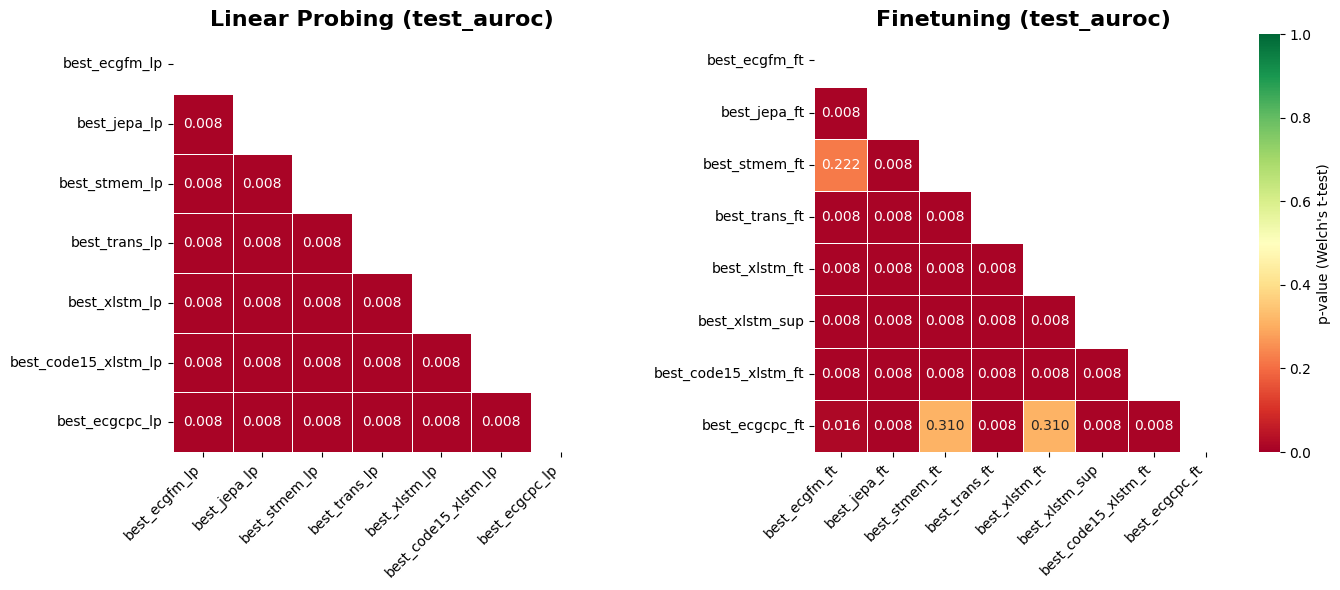

In [84]:
plot_pvalues_heatmap(
    pd.DataFrame(records_ptb_xl).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_auroc", 
    title="Pairwise P-Values for Test AUROC (PTB-XL)", 
    figsize=(14, 6)
)

## hyperparameters

In [105]:
records_configs_ptb_xl = get_records(
    "train-ptbxl-diagnosis_superclass-multilabel", 
    config=['lr_head','lr_xlstm', 'lr_core', 'layerwise_lr_decay', 'wd', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'epochs', 'use_final_layer_norm'],
    pattern=(lambda run: run.group in lp_groups),  
    regex="^best_"
)

configs_ptb_xl = pd.DataFrame(records_configs_ptb_xl).set_index("group")
# group by most occurrent column on group
most_occurrent_ptbxl = configs_ptb_xl.groupby('group').agg(lambda x: x[0])
most_occurrent_ptbxl.T

  0%|          | 0/126 [00:00<?, ?it/s]

 40%|████      | 51/126 [00:08<00:12,  5.97it/s]

100%|██████████| 126/126 [00:13<00:00,  9.61it/s]


/tmp/ipykernel_2816134/29076890.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_ptbxl = configs_ptb_xl.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_lp,best_ecgcpc_lp,best_ecgfm_lp,best_jepa_lp,best_stmem_lp,best_trans_lp,best_xlstm_lp
lr_head,0.001,1.0,0.001,0.001,0.001,0.001,0.001
lr_xlstm,0.00001,NaN,0.00001,0.00001,0.00001,0.0001,0.00001
layerwise_lr_decay,0,0,0,0,0,0,0
wd,0.1,0.001,0.1,0.1,0.1,0.1,0.1
cls_normalization,None,None,None,None,None,batch,None
cls_type,avg,avg,avg,avg,avg,avg,avg
drop_path_prob,False,False,False,False,False,False,False
batch_size,256,256,256,256,256,256,256
epochs,30,30,30,30,30,30,30
use_final_layer_norm,False,True,False,False,False,False,False


# CPSC 2018

In [36]:
records_cpsc = get_records("train-cpsc2018-multilabel", metrics=["test_acc", "test_f1", "test_auroc", "test_auprc", '_runtime'], regex="^best_")
formatted_df_cpsc = get_dataframe_from_records(records_cpsc)

100%|██████████| 135/135 [00:14<00:00,  9.55it/s]


## Finetuning

In [69]:
cpsc_ft = formatted_df_cpsc[formatted_df_cpsc.index.isin(ft_groups)]

styled_df_ft = cpsc_ft.style.apply(style_mean_column)
styled_df_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_code15_xlstm_ft,0.967 ± 0.001,0.817 ± 0.011,0.977 ± 0.003,0.878 ± 0.009,753.797 ± 5.855
best_ecgcpc_ft,0.915 ± 0.012,0.688 ± 0.078,0.943 ± 0.044,0.813 ± 0.080,457.162 ± 58.700
best_ecgfm_ft,0.964 ± 0.000,0.794 ± 0.005,0.969 ± 0.001,0.854 ± 0.002,406.169 ± 10.301
best_jepa_ft,0.942 ± 0.003,0.749 ± 0.009,0.965 ± 0.001,0.842 ± 0.003,1705.833 ± 44.027
best_stmem_ft,0.963 ± 0.001,0.789 ± 0.012,0.958 ± 0.003,0.835 ± 0.011,1314.123 ± 14.290
best_trans_ft,0.961 ± 0.001,0.796 ± 0.008,0.965 ± 0.003,0.853 ± 0.006,212.527 ± 12.297
best_xlstm_ft,0.968 ± 0.001,0.822 ± 0.008,0.981 ± 0.001,0.888 ± 0.003,731.973 ± 30.716
best_xlstm_sup,0.952 ± 0.001,0.719 ± 0.008,0.951 ± 0.002,0.813 ± 0.006,846.747 ± 71.359


## Linear probing

In [ ]:
formatted_df_cpsc_lp = formatted_df_cpsc[formatted_df_cpsc.index.str.endswith("_lp")]
styled_df_lp = formatted_df_cpsc_lp.style.apply(style_mean_column)
styled_df_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),test_auprc (mean ± std),_runtime (mean ± std)
,,,,,
group,,,,,
best_big_xlstm_lp,0.964 ± 0.001,0.792 ± 0.006,0.972 ± 0.000,0.869 ± 0.001,521.591 ± 6.325
best_code15_xlstm_lp,0.958 ± 0.001,0.757 ± 0.010,0.964 ± 0.001,0.842 ± 0.003,390.338 ± 11.351
best_ecgcpc_lp,0.936 ± 0.020,0.669 ± 0.084,0.909 ± 0.055,0.733 ± 0.078,300.030 ± 42.583
best_ecgfm_lp,0.958 ± 0.000,0.750 ± 0.007,0.962 ± 0.000,0.830 ± 0.001,252.192 ± 4.276
best_jepa_lp,0.889 ± 0.002,0.613 ± 0.003,0.961 ± 0.000,0.830 ± 0.001,746.866 ± 3.697
best_stmem_lp,0.935 ± 0.000,0.455 ± 0.005,0.922 ± 0.001,0.722 ± 0.004,604.956 ± 2.832
best_trans_lp,0.953 ± 0.001,0.733 ± 0.008,0.951 ± 0.001,0.787 ± 0.008,248.633 ± 32.202
best_xlstm_lp,0.961 ± 0.002,0.781 ± 0.011,0.968 ± 0.001,0.861 ± 0.004,461.689 ± 6.262


## latex table

In [95]:
print(df_to_latex_table_single_task(
    records_cpsc, rename_map_latex, 
    groups_ft= ft_groups_table,
    groups_lp= lp_groups,
    metrics=[
        ("test_acc", "Accuracy", 'max'),
        ("test_f1", "F1 Score", 'max'),
        ("test_auroc", "AUROC", 'max'),
        ("test_auprc", "AUPRC", 'max'),
    ],
    supervised_baselines=[],
    task_name='CPSC2018',
    caption= r"\textbf{CPSC2018.} Individual model performance for the CPSC2018 task. Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:cpsc2018_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cccc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{4}{c}{\textbf{CPSC2018}} \\
    & Accuracy& F1 Score& AUROC& AUPRC \\
    \midrule
    \multicolumn{5}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.952 $\pm$ 0.001 & 0.719 $\pm$ 0.008 & 0.951 $\pm$ 0.002 & 0.813 $\pm$ 0.006 \\
    \midrule
    \multicolumn{5}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & 0.935 $\pm$ 0.000 & 0.455 $\pm$ 0.005 & 0.922 $\pm$ 0.001 & 0.722 $\pm$ 0.004 \\
   ECG-JEPA & 0.889 $\pm$ 0.002 & 0.613 $\pm$ 0.003 & 0.961 $\pm$ 0.000 & 0.830 $\pm$ 0.001 \\
   ECGFounder & \underline{0.958 $\pm$ 0.000} & \underline{0.750 $\pm$ 0.007} & 0.962 $\pm$ 0.000 & 0.830 $\pm$ 0.001 \\
   ECG-CPC & 0.936 $\pm$ 0.020 & 0.669 $\pm$ 0.084 & 0.909 $\pm$ 0.055 & 0.733 $\pm$ 0.078 \\
   \textbf{SimDINOv2 Transf.} & 0.953 $\pm$ 0.001 & 0.733 $\pm$ 0.008 & 0.951 $\pm$ 0.001 & 0.787 $\pm$ 0.008 \\
   \textbf{xE

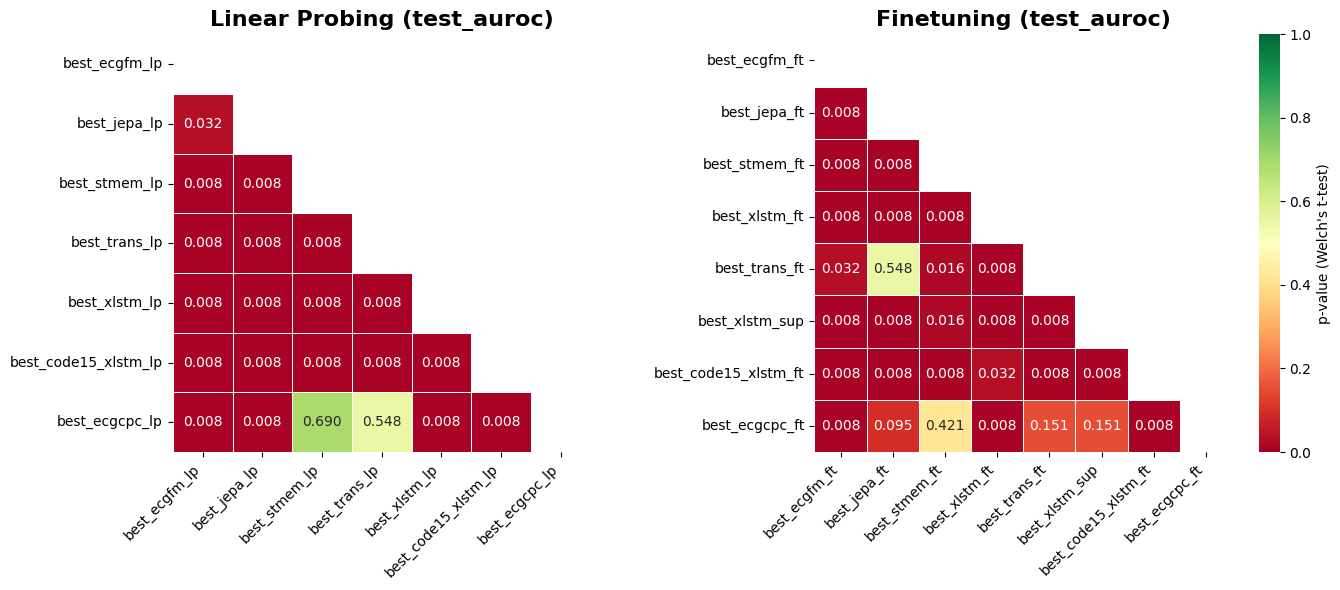

In [103]:
# plot the p-values heatmap for cpsc
plot_pvalues_heatmap(
    pd.DataFrame(records_cpsc).set_index("group"), 
    groups_ft=ft_groups_table,
    groups_lp=lp_groups,
    metric="test_auroc", 
    title="Pairwise P-Values for Test AUROC (CPSC2018)", 
    figsize=(14, 6)
)

In [14]:
records_configs_cpsc = get_records(
    "train-cpsc2018-multilabel", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm'],
    pattern=(lambda run: run.group in ft_groups),  
    regex="^best_"
)

configs_cpsc = pd.DataFrame(records_configs_cpsc).set_index("group")
# group by most occurrent column on group
most_occurrent_cpsc = configs_cpsc.groupby('group').agg(lambda x: x[0])
most_occurrent_cpsc.T

100%|██████████| 134/134 [00:14<00:00,  9.27it/s]
/tmp/ipykernel_1818895/983152280.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_cpsc = configs_cpsc.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_ft,best_ecgfm_ft,best_jepa_ft,best_stmem_ft,best_trans_ft,best_xlstm_ft,best_xlstm_sup
lr_head,0.001,0.001,0.001,0.0003,0.001,0.001,0.0001
lr_xlstm,0.00003,0.00001,0.00001,0.0003,0.00001,0.00003,0.0001
layerwise_lr_decay,0.75,1.0,0.75,0.75,0.75,0.75,0.0
wd,0.1,0.1,0.1,0.1,0.1,0.1,0.1
epochs,30,30,30,30,50,30,30
cls_normalization,None,None,None,None,batch,None,None
cls_type,max,max,max,max,max,max,max
drop_path_prob,0.5,0.0,0.5,0.5,0.0,0.5,0.0
batch_size,128,256,96,128,256,128,128
use_final_layer_norm,False,False,True,True,False,False,False


# MIT-BIH classification

In [15]:
records_mit_cls = get_records("train-mitbih-5", metrics=["test_acc", "test_sensitivity/mean", "test_ppv/mean", "test_specificity/mean", "test_f1/mean", '_runtime'], regex="^best_")
formatted_df_mit_cls = get_dataframe_from_records(records_mit_cls)

100%|██████████| 66/66 [00:02<00:00, 22.28it/s]

## Finetuning

In [16]:
mit_ft = formatted_df_mit_cls[formatted_df_mit_cls.index.isin(ft_groups)]

styled_df_mit_ft = mit_ft.style.apply(style_mean_column)
styled_df_mit_ft

,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_code15_xlstm_ft,0.916 ± 0.008,0.523 ± 0.020,0.480 ± 0.019,0.940 ± 0.003,0.481 ± 0.017,1045.752 ± 3.770
best_ecgfm_ft,0.863 ± 0.008,0.211 ± 0.002,0.207 ± 0.002,0.809 ± 0.002,0.207 ± 0.002,328.807 ± 9.122
best_jepa_ft,0.954 ± 0.001,0.557 ± 0.006,0.629 ± 0.007,0.951 ± 0.001,0.583 ± 0.007,2252.044 ± 15.465
best_stmem_ft,0.967 ± 0.002,0.625 ± 0.007,0.671 ± 0.013,0.965 ± 0.003,0.644 ± 0.007,1783.386 ± 26.314
best_trans_ft,0.896 ± 0.008,0.475 ± 0.002,0.457 ± 0.005,0.905 ± 0.001,0.425 ± 0.006,216.098 ± 25.243
best_xlstm_ft,0.976 ± 0.007,0.651 ± 0.035,0.721 ± 0.019,0.973 ± 0.010,0.677 ± 0.025,708.598 ± 34.795
best_xlstm_sup,0.896 ± 0.013,0.448 ± 0.028,0.416 ± 0.020,0.910 ± 0.004,0.402 ± 0.014,748.898 ± 4.569


## Linear probing

In [17]:
formatted_mit_lp = formatted_df_mit_cls[formatted_df_mit_cls.index.str.endswith("_lp")]
styled_df_mit_lp = formatted_mit_lp.style.apply(style_mean_column)
styled_df_mit_lp


,test_acc (mean ± std),test_sensitivity/mean (mean ± std),test_ppv/mean (mean ± std),test_specificity/mean (mean ± std),test_f1/mean (mean ± std),_runtime (mean ± std)
,,,,,,
group,,,,,,
best_code15_xlstm_lp,0.913 ± 0.009,0.498 ± 0.005,0.448 ± 0.017,0.930 ± 0.002,0.448 ± 0.010,382.368 ± 5.659
best_ecgcpc_lp,0.892 ± nan,0.369 ± nan,0.380 ± nan,0.895 ± nan,0.341 ± nan,143.237 ± nan
best_ecgfm_lp,0.865 ± 0.012,0.210 ± 0.004,0.209 ± 0.004,0.808 ± 0.003,0.206 ± 0.005,324.685 ± 14.280
best_jepa_lp,0.946 ± 0.000,0.470 ± 0.003,0.574 ± 0.003,0.933 ± 0.000,0.496 ± 0.003,891.782 ± 8.916
best_stmem_lp,0.937 ± 0.003,0.424 ± 0.027,0.507 ± 0.035,0.920 ± 0.003,0.436 ± 0.036,847.626 ± 47.748
best_trans_lp,0.931 ± 0.000,0.381 ± 0.004,0.549 ± 0.012,0.924 ± 0.004,0.395 ± 0.005,108.508 ± 2.805
best_xlstm_lp,0.972 ± 0.002,0.686 ± 0.021,0.669 ± 0.014,0.976 ± 0.003,0.674 ± 0.013,326.174 ± 3.404


## latex table

In [18]:
print(df_to_latex_table_single_task(
    records_mit_cls, rename_map_latex, 
    metrics=[
        ("test_acc", "Accuracy", "max"),
        ("test_sensitivity/mean", "Sensitivity", "max"),
        ("test_ppv/mean", "PPV", "max"),
        ("test_specificity/mean", "Specificity", "max"),
        ("test_f1/mean", "F1 Score", "max")
    ],
    supervised_baselines=[
        r"     Xia et al.\cite{xia2023transformer} & 0.976 & 0.510 & 0.563 & 0.930 & 0.529 \\",
        r"     Sellami et al. \cite{sellami2019robust} & 0.953 & 0.690 & 0.555 & 0.960 & 0.558 \\",
        r"     Li et al.\cite{li2022inter} & 0.889 & 0.521 & 0.568 & 0.947 & 0.533 \\",
        r"     Marinho et al. \cite{marinho2019novel} & 0.943 & 0.478 & - & 0.914 & - \\",
        r"     Li et al. \cite{li2019automated} & 0.914 & 0.616 & 0.489 & 0.950 & 0.539 \\"
    ],
    task_name='MIT-BIH',
    caption= 'Performance on the MIT-BIH arrhythmia dataset for multi-class classification considering all 5 different classes.',
    table_id='tab:mitbih_results'
))

test_acc
group                 best_trans_lp  best_xlstm_lp  best_ecgfm_lp  \
group                                                               
best_trans_lp          1.000000e+00   1.165987e-06       0.000245   
best_xlstm_lp          1.165987e-06   1.000000e+00       0.000024   
best_ecgfm_lp          2.445719e-04   2.397721e-05       1.000000   
best_stmem_lp          1.560886e-02   8.677604e-08       0.000096   
best_jepa_lp           4.565953e-11   1.091261e-05       0.000108   
best_code15_xlstm_lp   1.124709e-02   7.643963e-05       0.000141   

group                 best_stmem_lp  best_jepa_lp  best_code15_xlstm_lp  
group                                                                    
best_trans_lp          1.560886e-02  4.565953e-11              0.011247  
best_xlstm_lp          8.677604e-08  1.091261e-05              0.000076  
best_ecgfm_lp          9.647267e-05  1.082385e-04              0.000141  
best_stmem_lp          1.000000e+00  1.827130e-03              0.003

## hyperparameters

In [19]:
records_configs_mit_cls = get_records(
    "train-mitbih-5", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm', 'win_len',],
    pattern=(lambda run: run.group in lp_groups),  
    regex="^best_"
)

configs_mit_cls = pd.DataFrame(records_configs_mit_cls).set_index("group")
# group by most occurrent column on group
most_occurrent_mit_cls = configs_mit_cls.groupby('group').agg(lambda x: x[0])
most_occurrent_mit_cls.T

100%|██████████| 66/66 [00:02<00:00, 24.15it/s]
/tmp/ipykernel_1818895/2052146145.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_mit_cls = configs_mit_cls.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_lp,best_ecgfm_lp,best_jepa_lp,best_stmem_lp,best_trans_lp,best_xlstm_lp
lr_head,0.001,0.001,0.001,0.001,0.01,0.001
lr_core,0.00001,0.00001,0.00001,0.0003,0.00001,0.00001
layerwise_lr_decay,0,1,0,0,0,0
wd,0.1,0.1,0.1,0.1,0.1,0.1
epochs,20,20,20,20,20,20
cls_normalization,None,None,None,None,None,None
cls_type,None,avg,avg,avg,avg,avg
drop_path_prob,False,0,False,False,False,False
batch_size,64,256,96,96,96,64
use_final_layer_norm,False,True,True,True,True,False


# MIT-BIH r-peaks

In [106]:
records_mit_r_peaks = get_records("train-mitbih-r_peaks", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance", '_runtime'], regex="^best_")
formatted_df_mit_r_peaks = get_dataframe_from_records(records_mit_r_peaks)

100%|██████████| 75/75 [00:04<00:00, 17.66it/s]


## Fine-tuning

In [107]:
mit_r_peaks_ft = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.isin(ft_groups)]
# add sup rows to ft
styled_df_mit_r_peaks_ft = mit_r_peaks_ft.style.apply(style_mean_column)
styled_df_mit_r_peaks_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.987 ± 0.002,0.803 ± 0.003,7.774 ± 0.649,213.593 ± 5.798
best_ecgcpc_ft,0.904 ± 0.010,0.865 ± 0.012,112.951 ± 36.933,225.575 ± 2.906
best_ecgfm_ft,0.081 ± 0.006,0.011 ± 0.001,3794.272 ± 789.848,309.131 ± 14.947
best_jepa_ft,0.996 ± 0.000,0.909 ± 0.004,4.195 ± 0.059,1364.272 ± 16.953
best_stmem_ft,0.994 ± 0.001,0.937 ± 0.001,5.148 ± 0.403,1102.879 ± 9.398
best_trans_ft,0.983 ± 0.001,0.900 ± 0.001,7.587 ± 0.159,278.538 ± 11.780
best_xlstm_ft,0.995 ± 0.000,0.921 ± 0.001,5.208 ± 0.098,223.998 ± 15.288
best_xlstm_sup,0.980 ± 0.007,0.889 ± 0.012,8.217 ± 1.056,191.553 ± 22.564


## Linear probing

In [108]:
formatted_df_mit_r_peaks_lp = formatted_df_mit_r_peaks[formatted_df_mit_r_peaks.index.str.endswith("_lp")]
styled_df_mit_r_peaks_lp = formatted_df_mit_r_peaks_lp.style.apply(style_mean_column)
styled_df_mit_r_peaks_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.969 ± 0.002,0.658 ± 0.001,12.918 ± 0.521,134.130 ± 7.789
best_ecgcpc_lp,0.696 ± 0.014,0.494 ± 0.006,327.578 ± 38.207,113.028 ± 2.272
best_ecgfm_lp,0.073 ± 0.005,0.010 ± 0.001,4564.209 ± 630.534,309.113 ± 5.623
best_jepa_lp,0.976 ± 0.000,0.444 ± 0.001,6.858 ± 0.016,602.930 ± 14.573
best_stmem_lp,0.970 ± 0.001,0.564 ± 0.002,7.430 ± 0.139,502.377 ± 19.211
best_trans_lp,0.864 ± 0.001,0.476 ± 0.000,32.177 ± 0.086,150.891 ± 4.207
best_xlstm_lp,0.945 ± 0.005,0.590 ± 0.011,11.487 ± 0.283,143.034 ± 18.259


## latex table

In [ ]:
print(df_to_latex_table_single_task(
    records_mit_r_peaks, rename_map_latex, 
    metrics=[
        ("test_f1_150", "F1 Score (150ms)", "max"),
        ("test_f1_20", "F1 Score (20ms)", "max"),
        # ("test_avg_total_distance", "Avg. Distance", "min"),
    ],
    task_name='MIT-BIH (R-peak)',
    caption= r"\textbf{R-peak.} Individual model performance for the R-peak detection task (MIT-BIH). Each model is trained $5$ times and we report the mean$\pm$ standard deviation.  Pairwise differences between models were assessed using two-sided Welch's t-tests across independent runs, with significance defined as $p<0.05$. Bold results indicate best performance across models and underlined indicates 2nd best.",
    table_id='tab:mitbih_r_peak_results'
))

\begin{table*}[h!]
\centering
{\footnotesize
    \begin{tabular}{l|cc}
    \toprule
    \multirow{2}{*}{\textbf{Methods}} & \multicolumn{2}{c}{\textbf{MIT-BIH (R-peak)}} \\
    & F1 Score (150ms)& F1 Score (20ms) \\
    \midrule
    \multicolumn{3}{c}{\textbf{Supervised}} \\
    \midrule
   \textbf{Supervised xLSTM} & 0.980 $\pm$ 0.007 & 0.889 $\pm$ 0.012 \\
    \midrule
    \multicolumn{3}{c}{\textbf{Linear Probing}} \\
    \midrule
   ST-MEM & \underline{0.970 $\pm$ 0.001} & 0.564 $\pm$ 0.002 \\
   ECG-JEPA & \textbf{0.976 $\pm$ 0.000} & 0.444 $\pm$ 0.001 \\
   ECGFounder & 0.073 $\pm$ 0.005 & 0.010 $\pm$ 0.001 \\
   ECG-CPC & 0.696 $\pm$ 0.014 & 0.494 $\pm$ 0.006 \\
   \textbf{SimDINOv2 Transf.} & 0.864 $\pm$ 0.001 & 0.476 $\pm$ 0.000 \\
   \textbf{xECG (CODE-15\%)} & \underline{0.969 $\pm$ 0.002} & \textbf{0.658 $\pm$ 0.001} \\
   \textbf{xECG} & 0.945 $\pm$ 0.005 & \underline{0.590 $\pm$ 0.011} \\
    \midrule
    \multicolumn{3}{c}{\textbf{Finetuning}} \\
    \midrule
   ST-MEM &

## hyperparameters

In [24]:
records_configs_mit_rpeak = get_records(
    "train-mitbih-r_peaks", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm', 'win_len'],
    pattern=(lambda run: run.group in ft_groups),  
    regex="^best_"
)

configs_mit_rpeak = pd.DataFrame(records_configs_mit_rpeak).set_index("group")
# group by most occurrent column on group
most_occurrent_mit_rpeak = configs_mit_rpeak.groupby('group').agg(lambda x: x[0])
most_occurrent_mit_rpeak.T

100%|██████████| 65/65 [00:02<00:00, 24.03it/s]
/tmp/ipykernel_1818895/3869020384.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_mit_rpeak = configs_mit_rpeak.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_ft,best_ecgfm_ft,best_jepa_ft,best_stmem_ft,best_trans_ft,best_xlstm_ft,best_xlstm_sup
lr_head,0.001,0.001,0.001,0.01,0.01,0.001,0.01
lr_xlstm,0.001,0.00001,0.001,0.01,0.001,0.001,0.01
layerwise_lr_decay,0.75,1.0,0.75,0.75,0.75,0.75,0.75
wd,0.0,0.1,0.1,0.1,0.1,0.0,0.0
epochs,30,30,30,30,30,30,30
cls_normalization,None,None,None,None,None,None,None
cls_type,None,avg,avg,avg,avg,avg,avg
drop_path_prob,0.5,0.0,0.5,0.5,0.5,0.5,0.5
batch_size,96,256,96,96,96,96,96
use_final_layer_norm,False,True,True,True,False,False,False


# Exercise high intensity r peaks

In [25]:
records_exe_r = get_records("train-exercise-r_peak", metrics=["test_f1_150", "test_f1_20", "test_avg_total_distance", '_runtime'], regex="^best_")
formatted_df_exe_r = get_dataframe_from_records(records_exe_r)

100%|██████████| 65/65 [00:02<00:00, 24.20it/s]


In [27]:
# print all groups
print("Groups in formatted_df_exe_r:")
print(formatted_df_exe_r.index.tolist())

Groups in formatted_df_exe_r:
['best_code15_xlstm_ft', 'best_code15_xlstm_lp', 'best_ecgfm_ft', 'best_ecgfm_lp', 'best_jepa_ft', 'best_jepa_lp', 'best_stmem_ft', 'best_stmem_lp', 'best_trans_ft', 'best_trans_lp', 'best_xlstm_ft', 'best_xlstm_lp', 'best_xlstm_sup']


## Finetuning

In [92]:
exe_r_ft = formatted_df_exe_r[formatted_df_exe_r.index.isin(ft_groups)]
# add sup rows to ft
styled_df_exe_r_ft = exe_r_ft.style.apply(style_mean_column)
styled_df_exe_r_ft

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.993 ± 0.001,0.964 ± 0.002,4.729 ± 0.165,123.506 ± 5.526
best_ecgfm_ft,0.423 ± 0.006,0.082 ± 0.005,52.456 ± 1.812,67.094 ± 4.811
best_jepa_ft,0.975 ± 0.002,0.859 ± 0.007,3.735 ± 0.133,224.103 ± 11.883
best_stmem_ft,0.988 ± 0.002,0.986 ± 0.001,3.284 ± 0.456,202.898 ± 5.310
best_trans_ft,0.853 ± 0.008,0.633 ± 0.013,12.255 ± 0.406,167.247 ± 13.075
best_xlstm_ft,0.996 ± 0.001,0.968 ± 0.002,4.030 ± 0.181,132.044 ± 11.150
best_xlstm_sup,0.990 ± 0.002,0.966 ± 0.002,5.832 ± 0.507,106.686 ± 7.300


## Linear probing

In [93]:
formatted_exe_r_lp = formatted_df_exe_r[formatted_df_exe_r.index.str.endswith("_lp")]
styled_df_exe_r_lp = formatted_exe_r_lp.style.apply(style_mean_column)
styled_df_exe_r_lp

,test_f1_150 (mean ± std),test_f1_20 (mean ± std),test_avg_total_distance (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.960 ± 0.004,0.933 ± 0.003,14.864 ± 1.685,90.123 ± 5.161
best_ecgfm_lp,0.421 ± 0.016,0.083 ± 0.002,51.782 ± 2.769,74.321 ± 8.168
best_jepa_lp,0.924 ± 0.004,0.526 ± 0.007,13.661 ± 1.133,133.761 ± 3.757
best_stmem_lp,0.822 ± 0.018,0.627 ± 0.008,44.091 ± 10.828,135.491 ± 4.775
best_trans_lp,0.603 ± 0.003,0.301 ± 0.001,25.484 ± 0.299,88.007 ± 3.518
best_xlstm_lp,0.948 ± 0.004,0.892 ± 0.004,17.654 ± 1.130,82.185 ± 7.421


## latex table

In [30]:
print(df_to_latex_table_single_task(
    records_exe_r, rename_map_latex, 
    metrics=[
        ("test_f1_150", "F1 Score (150ms)", "max"),
        ("test_f1_20", "F1 Score (20ms)", "max"),
        # ("test_avg_total_distance", "Avg. Distance", "min"),
    ],
    task_name='Exercise (R-peak)',
    caption= 'Performance comparison on the High Intensity Exercise-ECG dataset on the R-peak detection task.',
    table_id='tab:exercise_r_peak_results'
))

test_f1_150
group                 best_ecgfm_lp  best_jepa_lp  best_trans_lp  \
group                                                              
best_ecgfm_lp          1.000000e+00  4.388695e-08   7.796913e-06   
best_jepa_lp           4.388695e-08  1.000000e+00   1.607050e-13   
best_trans_lp          7.796913e-06  1.607050e-13   1.000000e+00   
best_xlstm_lp          6.545990e-08  1.653684e-05   3.110717e-15   
best_stmem_lp          3.021284e-10  1.106467e-04   5.964221e-06   
best_code15_xlstm_lp   3.097803e-08  1.339778e-06   9.053756e-14   

group                 best_xlstm_lp  best_stmem_lp  best_code15_xlstm_lp  
group                                                                     
best_ecgfm_lp          6.545990e-08   3.021284e-10          3.097803e-08  
best_jepa_lp           1.653684e-05   1.106467e-04          1.339778e-06  
best_trans_lp          3.110717e-15   5.964221e-06          9.053756e-14  
best_xlstm_lp          1.000000e+00   5.569041e-05          2.014402

In [31]:
print(df_to_latex_table_2_task(
    task1_records=records_mit_r_peaks,
    task2_records=records_exe_r,
    name_map=rename_map_latex,
    metrics=[
        ("test_f1_150", "F1(150)ms", "max"),
        ("test_f1_20", "F1(20)ms", "max"),
        # ("test_avg_total_distance", "Avg. Distance", "min"),
    ],
    supervised_baselines=[],
    task1_name='MIT-BIH',
    task2_name="Intense Exercise DB",
    caption='Performance comparison on R-peak detection task on MIT-BIH and Intense Exercise datasets under linear evaluation and fine-tuning',
    table_id='r_peaks_results',
))

test_f1_150
group                 best_stmem_lp  best_trans_lp  best_xlstm_lp  \
group                                                               
best_stmem_lp          1.000000e+00   3.711005e-15   3.553629e-04   
best_trans_lp          3.711005e-15   1.000000e+00   3.281682e-06   
best_xlstm_lp          3.553629e-04   3.281682e-06   1.000000e+00   
best_ecgfm_lp          6.365657e-11   1.871249e-10   4.230587e-17   
best_jepa_lp           3.861175e-05   1.094250e-12   1.862226e-04   
best_code15_xlstm_lp   3.083483e-01   1.889408e-09   2.081407e-04   

group                 best_ecgfm_lp  best_jepa_lp  best_code15_xlstm_lp  
group                                                                    
best_stmem_lp          6.365657e-11  3.861175e-05          3.083483e-01  
best_trans_lp          1.871249e-10  1.094250e-12          1.889408e-09  
best_xlstm_lp          4.230587e-17  1.862226e-04          2.081407e-04  
best_ecgfm_lp          1.000000e+00  1.645219e-10          9.4871

## hyperparameters

In [26]:
records_configs_exe_r = get_records(
    "train-exercise-r_peak", 
    config=['lr_head','lr_xlstm', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm', 'max_length_signal'],
    pattern=(lambda run: run.group in lp_groups),  
    regex="^best_"
)

configs_mit_exer = pd.DataFrame(records_configs_exe_r).set_index("group")
# group by most occurrent column on group
most_occurrent_mit_exer = configs_mit_exer.groupby('group').agg(lambda x: x[0])
most_occurrent_mit_exer.T

100%|██████████| 65/65 [00:02<00:00, 24.93it/s]
/tmp/ipykernel_1818895/1564541106.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_mit_exer = configs_mit_exer.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_lp,best_ecgfm_lp,best_jepa_lp,best_stmem_lp,best_trans_lp,best_xlstm_lp
lr_head,0.1,0.001,0.1,0.01,0.1,0.1
lr_xlstm,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001
layerwise_lr_decay,0,1,0,0,0,0
wd,0.1,0.1,0.1,0.1,0.1,0.1
epochs,30,30,30,30,30,30
cls_normalization,None,None,None,None,None,None
cls_type,avg,avg,avg,avg,avg,avg
drop_path_prob,False,0,False,False,False,False
batch_size,8,8,8,8,8,8
use_final_layer_norm,False,True,True,True,True,False


# Sleep apnea

In [114]:
records_sleep_apnea_orig = get_records("train-sleep-apnea_bis", metrics=["test_acc", "test_f1", "test_auc", '_runtime'], regex="^best_")
# rename the columns to match other datasets

100%|██████████| 185/185 [00:22<00:00,  8.17it/s]


In [123]:
print(records_sleep_apnea_orig[-1])
# rename best_code_15_xlstm_ft_3m to best_code15_xlstm_ft
for record in records_sleep_apnea_orig:
    if record['group'] == 'best_code_15_xlstm_ft_3m':
        record['group'] = 'best_code15_xlstm_ft_3m'

print(records_sleep_apnea_orig[-1])

{'group': 'best_code15_xlstm_ft_3m', 'test_acc': 0.7904684543609619, 'test_f1': 0.712031900882721, 'test_auc': 0.8689862489700317, '_runtime': 7785.450776842}
{'group': 'best_code15_xlstm_ft_3m', 'test_acc': 0.7904684543609619, 'test_f1': 0.712031900882721, 'test_auc': 0.8689862489700317, '_runtime': 7785.450776842}


In [124]:
ft_groups_sa = ['best_stmem_ft_10s', 'best_jepa_ft_1m', 'best_ecgfm_ft_9m', 'best_trans_ft_9m', 'best_xlstm_ft_5m','best_xlstm_sup', 'best_code15_xlstm_ft_3m']

# keep only idxs in ft_groups_sa
records_sleep_apnea = [record.copy() for record in records_sleep_apnea_orig if record['group'] in ft_groups_sa + lp_groups]
print([record['group'] for record in records_sleep_apnea])
# rename the groups to remove the time suffix

for record in records_sleep_apnea:
    if not record['group'].endswith('sup') and not record['group'].endswith('lp'):
        record['group'] = record['group'].rsplit('_', 1)[0]

# print(records_sleep_apnea)
formatted_df_sleep_apnea = get_dataframe_from_records(records_sleep_apnea)
# print(formatted_df_sleep_apnea)
print(formatted_df_sleep_apnea.index.tolist())

['best_xlstm_ft_5m', 'best_ecgfm_ft_9m', 'best_trans_ft_9m', 'best_jepa_ft_1m', 'best_xlstm_ft_5m', 'best_xlstm_ft_5m', 'best_xlstm_ft_5m', 'best_xlstm_ft_5m', 'best_trans_ft_9m', 'best_trans_ft_9m', 'best_trans_ft_9m', 'best_trans_ft_9m', 'best_ecgfm_ft_9m', 'best_ecgfm_ft_9m', 'best_ecgfm_ft_9m', 'best_ecgfm_ft_9m', 'best_jepa_ft_1m', 'best_jepa_ft_1m', 'best_jepa_ft_1m', 'best_jepa_ft_1m', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_stmem_ft_10s', 'best_xlstm_lp', 'best_xlstm_lp', 'best_ecgfm_lp', 'best_stmem_lp', 'best_jepa_lp', 'best_xlstm_lp', 'best_xlstm_lp', 'best_xlstm_lp', 'best_stmem_lp', 'best_stmem_lp', 'best_stmem_lp', 'best_stmem_lp', 'best_trans_lp', 'best_trans_lp', 'best_trans_lp', 'best_trans_lp', 'best_trans_lp', 'best_ecgfm_lp', 'best_ecgfm_lp', 'best_ecgfm_lp', 'best_ecgfm_lp', 'best_jepa_lp', 'best_jepa_lp', 'best_jepa_lp', 'best_jepa_lp', 'best_xlstm_sup', 'best_xlstm_sup', 'best_xlstm_sup', 'best_xlstm_sup', 'best_x

## Fine-tuning

In [125]:
sleep_ft = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.isin(ft_groups)]
# add sup rows to ft
styled_df_sleep_ft = sleep_ft.style.apply(style_mean_column)
styled_df_sleep_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.797 ± 0.015,0.712 ± 0.030,0.875 ± 0.007,7760.303 ± 18.661
best_ecgfm_ft,0.726 ± 0.048,0.647 ± 0.035,0.778 ± 0.072,25151.781 ± 199.422
best_jepa_ft,0.643 ± 0.016,0.461 ± 0.071,0.690 ± 0.028,47518.183 ± 356.468
best_stmem_ft,0.587 ± 0.053,0.581 ± 0.061,0.700 ± 0.030,9480.466 ± 59.347
best_trans_ft,0.615 ± 0.053,0.565 ± 0.035,0.681 ± 0.044,23044.163 ± 28.958
best_xlstm_ft,0.854 ± 0.012,0.807 ± 0.025,0.928 ± 0.008,7756.403 ± 37.884
best_xlstm_sup,0.754 ± 0.032,0.675 ± 0.050,0.834 ± 0.020,9519.120 ± 29.350


## Linear probing

In [126]:
formatted_sleep_lp = formatted_df_sleep_apnea[formatted_df_sleep_apnea.index.str.endswith("_lp")]
styled_df_sleep_lp = formatted_sleep_lp.style.apply(style_mean_column)
styled_df_sleep_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.734 ± 0.031,0.641 ± 0.033,0.796 ± 0.034,3617.387 ± 9.267
best_ecgfm_lp,0.727 ± 0.059,0.666 ± 0.065,0.777 ± 0.071,6870.415 ± 225.842
best_jepa_lp,0.629 ± 0.041,0.464 ± 0.109,0.667 ± 0.051,19997.856 ± 175.868
best_stmem_lp,0.559 ± 0.020,0.554 ± 0.020,0.599 ± 0.032,3977.423 ± 16.073
best_trans_lp,0.668 ± 0.037,0.646 ± 0.043,0.644 ± 0.042,412.091 ± 10.735
best_xlstm_lp,0.812 ± 0.016,0.744 ± 0.032,0.879 ± 0.021,3660.922 ± 14.977


## hyperparams

In [34]:
records_configs_sa = get_records(
    "train-sleep-apnea_bis", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm', 'max_length_signal', 'window_size', 'context_size'],
    pattern=(lambda run: run.group in ft_groups_sa),  
    regex="^best_"
)

configs_mit_sa = pd.DataFrame(records_configs_sa).set_index("group")
# group by most occurrent column on group
most_occurrent_mit_sa = configs_mit_sa.groupby('group').agg(lambda x: x[0])
most_occurrent_mit_sa.T

100%|██████████| 185/185 [00:22<00:00,  8.36it/s]
/tmp/ipykernel_1818895/3758231077.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_mit_sa = configs_mit_sa.groupby('group').agg(lambda x: x[0])


group,best_code_15_xlstm_ft_3m,best_ecgfm_ft_9m,best_jepa_ft_1m,best_stmem_ft_10s,best_trans_ft_9m,best_xlstm_ft_5m,best_xlstm_sup
lr_head,0.0003,0.0003,0.001,0.0003,0.0003,0.0003,0.0001
lr_xlstm,0.00003,0.0,0.000001,0.0003,0.00003,0.00003,0.0001
layerwise_lr_decay,0.75,1.0,0.75,0.75,0.75,0.75,1.0
wd,0.1,0.1,0.1,0.1,0.1,0.1,0.0
epochs,20,20,20,20,20,20,20
cls_normalization,None,None,None,None,None,None,None
cls_type,max,avg,avg,avg,avg,max,max
drop_path_prob,0.5,0.0,0.5,0.5,0.5,0.5,0.0
batch_size,32,16,4,96,8,32,32
use_final_layer_norm,False,True,True,True,False,False,False


## latex table

In [70]:
rename_map_sa = {
    "best_stmem_ft": "ST-MEM",
    "best_stmem_lp": "ST-MEM",
    "best_jepa_ft": "ECG-JEPA",
    "best_jepa_lp": "ECG-JEPA",
    "best_ecgfm_ft": "ECGFounder",
    "best_ecgfm_lp": "ECGFounder",
    "best_trans_ft": "\\textbf{SimDINOv2 Transformer}",
    "best_trans_lp": "\\textbf{SimDINOv2 Transformer}",
    "best_xlstm_ft": "\\textbf{xECG}",
    "best_xlstm_ft": "\\textbf{xECG}",
    "best_xlstm_lp": "\\textbf{xECG}",
    "best_xlstm_sup": "\\textbf{Supervised xLSTM}",
    "best_code_15_xlstm_ft": "\\textbf{xECG (code15)}",
    "best_code15_xlstm_lp": "\\textbf{xECG (code15)}",
    "best_code15_xlstm_ft": "\\textbf{xECG (code15)}",
}

print(df_to_latex_table_single_task(
    records_sleep_apnea, rename_map_sa, 
    metrics=[
        ("test_acc", "Accuracy", "max"),
        ("test_f1", "F1 Score", "max"),
        ('test_auc', "AUROC", "max")
    ],
    supervised_baselines=[
        r"     Chang et al.\cite{chang2020sleep} &  0.920 &  0.879 &  0.865 \\",
        r"     Shen et al. \cite{shen2021multiscale} &  0.894 & 0.866 & 0.946 \\",
        r"     Bernardini et al. \cite{Bernardini2021AIOSASleepApnea} & 0.936 &  0.916 & 0.981 \\"
    ],
    groups_ft = ft_groups + ['best_code15_xlstm_ft'], #ft_groups_sa[:-1], # , 'best_xlstm_sup'],
    task_name='Physionet Sleep Apnea-ECG',
    caption= 'Individual model performance for the Sleep Apnea task (sleep apnea segmentation Apnea-ECG). Each model is trained 5 times and we report the mean± standard deviation. Pairwise differences between models were assessed using two-sided Welch’s t-tests across independent runs, with significance defined as p < 0.05. Bold results indicate best performance across models and underlined indicates 2nd best.',
    table_id='tab:sleep_apnea_results',
))

test_acc
group                 best_xlstm_lp  best_ecgfm_lp  best_stmem_lp  \
group                                                               
best_xlstm_lp          1.000000e+00       0.030543   3.982125e-08   
best_ecgfm_lp          3.054281e-02       1.000000   1.928144e-03   
best_stmem_lp          3.982125e-08       0.001928   1.000000e+00   
best_jepa_lp           2.184557e-04       0.018600   1.515993e-02   
best_trans_lp          3.293283e-04       0.099906   1.053957e-03   
best_code15_xlstm_lp   2.549228e-03       0.824553   1.692552e-05   

group                 best_jepa_lp  best_trans_lp  best_code15_xlstm_lp  
group                                                                    
best_xlstm_lp             0.000218       0.000329              0.002549  
best_ecgfm_lp             0.018600       0.099906              0.824553  
best_stmem_lp             0.015160       0.001054              0.000017  
best_jepa_lp              1.000000       0.161320              0.002

KeyError: 'best_code15_xlstm_ft'

# PPG

In [71]:
records_ppg = get_records("train-deepbeat", metrics=["test_acc", "test_f1", "test_auroc", '_runtime'], regex="^best_")
formatted_df_ppg = get_dataframe_from_records(records_ppg)

100%|██████████| 75/75 [00:04<00:00, 17.65it/s]


## hyperparameters

In [72]:
records_configs_ppg = get_records(
    "train-deepbeat", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm'],
    pattern=(lambda run: run.group in ft_groups),  
    regex="^best_"
)

configs_ppg = pd.DataFrame(records_configs_ppg).set_index("group")
# group by most occurrent column on group
most_occurrent_ppg = configs_ppg.groupby('group').agg(lambda x: x[0])
most_occurrent_ppg.T

100%|██████████| 75/75 [00:04<00:00, 17.68it/s]
/tmp/ipykernel_1818895/4248494432.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_ppg = configs_ppg.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_ft,best_ecgfm_ft,best_jepa_ft,best_stmem_ft,best_trans_ft,best_xlstm_ft,best_xlstm_sup
lr_head,0.001,0.01,0.001,0.0003,0.001,0.001,0.0001
lr_xlstm,0.00001,0.001,0.00001,0.0003,0.0001,0.00001,0.0001
layerwise_lr_decay,1.0,1.0,0.75,0.75,0.75,1.0,1.0
wd,0.1,0.1,0.1,0.1,0.1,0.1,0.1
epochs,30,30,30,30,30,30,30
cls_normalization,None,None,None,None,None,None,None
cls_type,avg,avg,avg,avg,avg,avg,avg
drop_path_prob,0.0,0.0,0.5,0.5,0.5,0.0,0.0
batch_size,128,128,96,128,256,128,128
use_final_layer_norm,False,True,True,True,True,False,False


## Fine-tuning

In [73]:
ppg_ft = formatted_df_ppg[formatted_df_ppg.index.isin(ft_groups)]
styled_df_ppg_ft = ppg_ft.style.apply(style_mean_column)
styled_df_ppg_ft

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.771 ± 0.027,0.731 ± 0.024,0.875 ± 0.010,3530.360 ± 572.245
best_ecgfm_ft,0.722 ± 0.048,0.686 ± 0.031,0.846 ± 0.012,1778.022 ± 255.429
best_jepa_ft,0.698 ± 0.029,0.660 ± 0.022,0.818 ± 0.021,23075.920 ± 13336.132
best_stmem_ft,0.616 ± 0.065,0.555 ± 0.030,0.643 ± 0.049,13791.445 ± 2142.318
best_trans_ft,0.660 ± 0.034,0.626 ± 0.020,0.780 ± 0.014,1731.920 ± 453.099
best_xlstm_ft,0.782 ± 0.015,0.740 ± 0.016,0.883 ± 0.019,5369.646 ± 1081.716
best_xlstm_sup,0.771 ± 0.016,0.733 ± 0.012,0.876 ± 0.006,7756.126 ± 1091.990


## Linear probing

In [74]:
formatted_df_ppg_lp = formatted_df_ppg[formatted_df_ppg.index.str.endswith("_lp")]
styled_df_ppg_lp = formatted_df_ppg_lp.style.apply(style_mean_column)
styled_df_ppg_lp

,test_acc (mean ± std),test_f1 (mean ± std),test_auroc (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.548 ± 0.035,0.532 ± 0.028,0.715 ± 0.018,2144.758 ± 153.068
best_ecgfm_lp,0.714 ± 0.064,0.491 ± 0.072,0.641 ± 0.019,781.726 ± 197.233
best_jepa_lp,0.524 ± 0.010,0.448 ± 0.007,0.477 ± 0.006,4359.214 ± 1837.851
best_stmem_lp,0.667 ± 0.048,0.560 ± 0.018,0.653 ± 0.006,8258.390 ± 1387.931
best_trans_lp,0.618 ± 0.034,0.562 ± 0.010,0.656 ± 0.003,1084.105 ± 55.174
best_xlstm_lp,0.701 ± 0.061,0.616 ± 0.034,0.751 ± 0.013,4178.340 ± 67.870


## latex table

In [77]:
print(df_to_latex_table_single_task(
    records_ppg, rename_map_latex, 
    metrics=[
        ("test_acc", "Accuracy", "max"),
        ("test_f1", "F1 Score", "max"),
        ('test_auroc', "AUROC", "max")
    ],
    task_name='DeepBeat PPG',
    caption= 'Performance comparison for AF classification on the DeepBeat PPG dataset',
    table_id='tab:ppg_results'
))

test_acc
group                 best_jepa_lp  best_ecgfm_lp  best_stmem_lp  \
group                                                              
best_jepa_lp              1.000000       0.002542       0.002399   
best_ecgfm_lp             0.002542       1.000000       0.224959   
best_stmem_lp             0.002399       0.224959       1.000000   
best_trans_lp             0.002902       0.024868       0.105357   
best_xlstm_lp             0.002779       0.758242       0.349145   
best_code15_xlstm_lp      0.214301       0.002026       0.002594   

group                 best_trans_lp  best_xlstm_lp  best_code15_xlstm_lp  
group                                                                     
best_jepa_lp               0.002902       0.002779              0.214301  
best_ecgfm_lp              0.024868       0.758242              0.002026  
best_stmem_lp              0.105357       0.349145              0.002594  
best_trans_lp              1.000000       0.036158              0.01269

KeyError: 'best_code_15_xlstm_ft'

# AGE prediction

In [80]:
records_age = get_records("train-age", metrics=[
    "test_rsmape_0_mimic/dataloader_idx_1", "test_mae_mimic/dataloader_idx_1", 
    "test_rsmape_0_ptbxl/dataloader_idx_0", "test_mae_ptbxl/dataloader_idx_0",
    "test_rsmape_0_cpsc/dataloader_idx_2", "test_mae_cpsc/dataloader_idx_2", '_runtime'], history=[('valid_mae', 'min'), ('valid_rsmape_0', 'min')])

def add_mean_age(df):
    df['mean_mae'] = (df['test_mae_mimic/dataloader_idx_1'] + df['test_mae_ptbxl/dataloader_idx_0'] + df['test_mae_cpsc/dataloader_idx_2']) / 3
    df['mean_rsmape'] = (df['test_rsmape_0_mimic/dataloader_idx_1'] + df['test_rsmape_0_ptbxl/dataloader_idx_0'] + df['test_rsmape_0_cpsc/dataloader_idx_2']) / 3
    df['val_test_diff_mae'] = df['valid_mae'] - df['mean_mae']
    return df

formatted_df_age = get_dataframe_from_records(records_age, add_custom_columns=add_mean_age)

100%|██████████| 65/65 [02:08<00:00,  1.97s/it]


## Finetuning

In [83]:
age_ft = formatted_df_age[formatted_df_age.index.isin(ft_groups)]
# add two column, one for the average of mae and one for the average of rsmape
styled_df_age_ft = age_ft.style.apply(style_mean_column_min)
styled_df_age_ft

,test_rsmape_0_mimic/dataloader_idx_1 (mean ± std),test_mae_mimic/dataloader_idx_1 (mean ± std),test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std),test_mae_ptbxl/dataloader_idx_0 (mean ± std),test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std),test_mae_cpsc/dataloader_idx_2 (mean ± std),_runtime (mean ± std),valid_mae (mean ± std),valid_rsmape_0 (mean ± std),mean_mae (mean ± std),mean_rsmape (mean ± std),val_test_diff_mae (mean ± std)
,,,,,,,,,,,,
group,,,,,,,,,,,,
best_code15_xlstm_ft,0.077 ± 0.000,9.239 ± 0.040,0.073 ± 0.000,8.073 ± 0.014,0.079 ± 0.001,8.361 ± 0.060,2961.143 ± 12.868,7.092 ± 0.020,0.073 ± 0.000,8.557 ± 0.030,0.076 ± 0.000,-1.465 ± 0.037
best_ecgfm_ft,0.075 ± 0.001,9.061 ± 0.139,0.072 ± 0.002,7.884 ± 0.223,0.078 ± 0.001,8.260 ± 0.168,2535.691 ± 193.368,6.674 ± 0.055,0.069 ± 0.000,8.401 ± 0.167,0.075 ± 0.001,-1.727 ± 0.171
best_jepa_ft,0.073 ± 0.001,8.849 ± 0.123,0.070 ± 0.002,7.927 ± 0.195,0.075 ± 0.001,8.169 ± 0.118,33186.464 ± 1926.168,6.370 ± 0.020,0.066 ± 0.000,8.315 ± 0.130,0.073 ± 0.001,-1.945 ± 0.122
best_stmem_ft,0.069 ± 0.001,8.247 ± 0.087,0.067 ± 0.001,7.393 ± 0.123,0.068 ± 0.001,7.245 ± 0.133,13315.785 ± 773.482,6.016 ± 0.048,0.062 ± 0.000,7.628 ± 0.107,0.068 ± 0.001,-1.612 ± 0.109
best_trans_ft,0.083 ± 0.001,9.866 ± 0.069,0.079 ± 0.001,8.664 ± 0.068,0.088 ± 0.001,9.303 ± 0.073,1572.466 ± 4.564,7.895 ± 0.037,0.082 ± 0.000,9.278 ± 0.045,0.083 ± 0.000,-1.383 ± 0.066
best_xlstm_ft,0.073 ± 0.000,8.818 ± 0.040,0.070 ± 0.000,7.670 ± 0.036,0.075 ± 0.001,7.943 ± 0.068,2963.646 ± 13.937,6.727 ± 0.013,0.070 ± 0.000,8.144 ± 0.037,0.073 ± 0.000,-1.417 ± 0.040
best_xlstm_sup,0.079 ± 0.001,9.464 ± 0.124,0.075 ± 0.001,8.229 ± 0.081,0.082 ± 0.001,8.754 ± 0.121,2210.471 ± 153.178,7.931 ± 0.045,0.082 ± 0.000,8.816 ± 0.104,0.078 ± 0.001,-0.885 ± 0.061


## linear probing

In [84]:
age_lp = formatted_df_age[formatted_df_age.index.str.endswith("_lp")]
styled_df_age_lp = age_lp.style.apply(style_mean_column_min)
styled_df_age_lp

,test_rsmape_0_mimic/dataloader_idx_1 (mean ± std),test_mae_mimic/dataloader_idx_1 (mean ± std),test_rsmape_0_ptbxl/dataloader_idx_0 (mean ± std),test_mae_ptbxl/dataloader_idx_0 (mean ± std),test_rsmape_0_cpsc/dataloader_idx_2 (mean ± std),test_mae_cpsc/dataloader_idx_2 (mean ± std),_runtime (mean ± std),valid_mae (mean ± std),valid_rsmape_0 (mean ± std),mean_mae (mean ± std),mean_rsmape (mean ± std),val_test_diff_mae (mean ± std)
,,,,,,,,,,,,
group,,,,,,,,,,,,
best_code15_xlstm_lp,0.082 ± 0.000,9.835 ± 0.009,0.077 ± 0.000,8.586 ± 0.008,0.085 ± 0.000,9.084 ± 0.014,1522.523 ± 151.576,8.435 ± 0.019,0.088 ± 0.000,9.168 ± 0.005,0.082 ± 0.000,-0.733 ± 0.022
best_ecgfm_lp,0.077 ± 0.000,9.298 ± 0.019,0.073 ± 0.000,8.098 ± 0.017,0.081 ± 0.000,8.595 ± 0.014,3779.748 ± 10.255,7.619 ± 0.026,0.079 ± 0.000,8.663 ± 0.005,0.077 ± 0.000,-1.045 ± 0.025
best_jepa_lp,0.083 ± 0.000,9.980 ± 0.018,0.076 ± 0.000,8.389 ± 0.008,0.083 ± 0.000,8.899 ± 0.017,14682.076 ± 31.888,7.967 ± 0.015,0.083 ± 0.000,9.089 ± 0.006,0.081 ± 0.000,-1.122 ± 0.019
best_stmem_lp,0.098 ± 0.000,11.566 ± 0.025,0.089 ± 0.000,9.804 ± 0.004,0.104 ± 0.000,11.151 ± 0.026,9754.940 ± 38.083,12.313 ± 0.027,0.127 ± 0.000,10.840 ± 0.015,0.097 ± 0.000,1.473 ± 0.022
best_trans_lp,0.086 ± 0.000,10.284 ± 0.025,0.085 ± 0.000,9.253 ± 0.025,0.094 ± 0.000,9.959 ± 0.025,1569.868 ± 3.924,9.441 ± 0.025,0.098 ± 0.000,9.832 ± 0.016,0.088 ± 0.000,-0.391 ± 0.032
best_xlstm_lp,0.078 ± 0.000,9.334 ± 0.011,0.073 ± 0.000,7.989 ± 0.006,0.080 ± 0.000,8.489 ± 0.006,1581.337 ± 4.903,8.824 ± 0.024,0.092 ± 0.000,8.604 ± 0.004,0.077 ± 0.000,0.220 ± 0.025


## hyperparameters

In [78]:
records_configs_age = get_records(
    "train-age", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm'],
    pattern=(lambda run: run.group in ft_groups),  
    regex="^best_"
)

configs_age = pd.DataFrame(records_configs_age).set_index("group")
# group by most occurrent column on group
most_occurrent_age = configs_age.groupby('group').agg(lambda x: x[0])
most_occurrent_age.T

100%|██████████| 65/65 [00:02<00:00, 24.23it/s]
/tmp/ipykernel_1818895/443805117.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_age = configs_age.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_ft,best_ecgfm_ft,best_jepa_ft,best_stmem_ft,best_trans_ft,best_xlstm_ft,best_xlstm_sup
lr_head,0.01,0.1,0.1,0.0003,0.01,0.01,0.001
lr_xlstm,0.00003,0.001,0.0001,0.0003,0.0001,0.00003,0.001
layerwise_lr_decay,0.75,1.0,0.75,0.75,0.75,0.75,0.75
wd,0.1,0.01,0.01,0.01,0.01,0.1,0.01
epochs,15,15,15,15,15,15,15
cls_normalization,None,None,None,None,None,None,None
cls_type,avg,avg,avg,avg,avg,avg,avg
drop_path_prob,0.2,0.0,0.5,0.0,0.0,0.2,0.5
batch_size,512,512,96,128,512,512,512
use_final_layer_norm,False,True,True,True,False,False,False


## Latex table generation

In [ ]:
def format_df_add_mean(df):
    df['mean_mae'] = df[['test_mae_mimic/dataloader_idx_1', 'test_mae_ptbxl/dataloader_idx_0', 'test_mae_cpsc/dataloader_idx_2']].mean(axis=1)
    df['mean_rsmape'] = df[['test_rsmape_0_mimic/dataloader_idx_1', 'test_rsmape_0_ptbxl/dataloader_idx_0', 'test_rsmape_0_cpsc/dataloader_idx_2']].mean(axis=1)
    return df

print(df_to_latex_table_single_task(
    records_age, rename_map_latex, 
    metrics=[
        ("valid_mae", "MAE (CODE-15%)", "min"),
        ("test_mae_mimic/dataloader_idx_1", "MAE (MIMIC-IV)", "min"),
        ("test_mae_ptbxl/dataloader_idx_0", "MAE (PTB-XL)", "min"),
        ("test_mae_cpsc/dataloader_idx_2", "MAE (CPSC)", "min"),
        ("mean_mae", "MAE (mean)", "min"),
    ],
    task_name='Age Prediction',
    caption= 'Mean absolute error comparison for age prediction trained on CODE-15 and tested on MIMIC-IV, PTB-XL, and CPSC2018 datasets.',
    table_id='tab:age_results_mae',
    format_dataframe=format_df_add_mean
))

print(df_to_latex_table_single_task(
    records_age, rename_map_latex, 
    metrics=[
        ("valid_rsmape_0", "CODE-15/%", "min"),
        ("test_rsmape_0_mimic/dataloader_idx_1", "MIMIC-IV", "min"),
        ("test_rsmape_0_ptbxl/dataloader_idx_0", "PTB-XL", "min"),
        ("test_rsmape_0_cpsc/dataloader_idx_2", "CPSC", "min"),
        ("mean_rsmape", "SMAPE (mean)", "min"),
    ],
    task_name='Age Prediction',
    caption= 'Symmetric mean absolute percentage error comparison for age prediction trained on CODE-15 and tested on MIMIC-IV-ECG, PTB-XL, and CPSC2018 datasets.',
    table_id='tab:age_results_rsmape',
    format_dataframe=format_df_add_mean
))

valid_mae
group                 best_ecgfm_lp  best_jepa_lp  best_stmem_lp  \
group                                                              
best_ecgfm_lp          1.000000e+00  1.084769e-07   3.459126e-17   
best_jepa_lp           1.084769e-07  1.000000e+00   2.745941e-14   
best_stmem_lp          3.459126e-17  2.745941e-14   1.000000e+00   
best_trans_lp          4.606903e-14  4.065691e-12   1.785662e-15   
best_xlstm_lp          1.221661e-12  8.715188e-11   4.246454e-16   
best_code15_xlstm_lp   6.865127e-11  2.206457e-10   1.973882e-15   

group                 best_trans_lp  best_xlstm_lp  best_code15_xlstm_lp  
group                                                                     
best_ecgfm_lp          4.606903e-14   1.221661e-12          6.865127e-11  
best_jepa_lp           4.065691e-12   8.715188e-11          2.206457e-10  
best_stmem_lp          1.785662e-15   4.246454e-16          1.973882e-15  
best_trans_lp          1.000000e+00   1.735369e-10          6.566240e-

# LAB tests

In [94]:
lab_test_records = get_records("train-lab", metrics=["test_auroc_avg", "test_f1_avg", "test_acc_avg", '_runtime'], regex="^best_")
formatted_df_lab_tests = get_dataframe_from_records(lab_test_records)

100%|██████████| 66/66 [00:02<00:00, 23.24it/s]

## Finetuning

In [127]:
lab_ft = formatted_df_lab_tests[formatted_df_lab_tests.index.isin(ft_groups)]
styled_lab_ft = lab_ft.style.apply(style_mean_column)
styled_lab_ft

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,0.733 ± 0.001,0.439 ± 0.002,0.443 ± 0.001,3426.992 ± 40.513
best_ecgfm_ft,0.714 ± 0.003,0.437 ± 0.003,0.440 ± 0.002,2005.857 ± 69.147
best_jepa_ft,0.735 ± 0.001,0.434 ± 0.001,0.440 ± 0.000,54315.083 ± 6558.821
best_stmem_ft,0.744 ± 0.002,0.457 ± 0.002,0.456 ± 0.002,53819.958 ± 4479.778
best_trans_ft,0.725 ± 0.001,0.443 ± 0.005,0.445 ± 0.004,2444.767 ± 238.973
best_xlstm_ft,0.747 ± 0.002,0.450 ± 0.002,0.451 ± 0.001,3425.334 ± 46.406
best_xlstm_sup,0.683 ± 0.001,0.421 ± 0.003,0.425 ± 0.004,1806.360 ± 16.136


## linear probing

In [96]:
lab_lp = formatted_df_lab_tests[formatted_df_lab_tests.index.str.endswith("_lp")]
styled_lab_lp = lab_lp.style.apply(style_mean_column)
styled_lab_lp

,test_auroc_avg (mean ± std),test_f1_avg (mean ± std),test_acc_avg (mean ± std),_runtime (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,0.715 ± 0.001,0.426 ± 0.000,0.433 ± 0.000,2577.530 ± 71.305
best_ecgfm_lp,0.711 ± 0.000,0.424 ± 0.000,0.430 ± 0.000,2212.457 ± 48.178
best_jepa_lp,0.722 ± 0.000,0.424 ± 0.000,0.432 ± 0.000,10821.596 ± 31.429
best_stmem_lp,0.708 ± 0.000,0.416 ± 0.000,0.424 ± 0.000,6531.244 ± 3183.321
best_trans_lp,0.724 ± 0.001,0.431 ± 0.000,0.437 ± 0.000,2069.505 ± 32.188
best_xlstm_lp,0.733 ± 0.000,0.435 ± 0.001,0.439 ± 0.000,2506.129 ± 32.718


## hyperparameters

In [ ]:
records_configs_lab = get_records(
    "train-lab", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm'],
    pattern=(lambda run: run.group in lp_groups),  
    regex="^best_"
)

configs_lab = pd.DataFrame(records_configs_lab).set_index("group")
# group by most occurrent column on group
most_occurrent_lab = configs_lab.groupby('group').agg(lambda x: x[0])
most_occurrent_lab.T

100%|██████████| 66/66 [00:02<00:00, 23.84it/s]
/tmp/ipykernel_1811259/625638926.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_lab = configs_lab.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_lp,best_ecgfm_lp,best_jepa_lp,best_stmem_lp,best_trans_lp,best_xlstm_lp
lr_head,0.001,0.001,0.003,0.01,0.001,0.001
lr_core,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001
layerwise_lr_decay,0,0,0,0,0,0
wd,0.1,0.1,0.1,0.1,0.1,0.1
epochs,20,20,20,20,20,20
cls_normalization,None,None,None,None,batch,None
cls_type,avg,avg,avg,avg,avg,avg
drop_path_prob,False,False,False,False,False,False
batch_size,512,512,512,512,512,512
use_final_layer_norm,False,False,False,False,False,False


## latex table

In [ ]:
print(df_to_latex_table_single_task(
    lab_test_records, rename_map_latex, 
    metrics=[
        ("test_acc_avg", "Accuracy", 'max'),
        ("test_f1_avg", "F1 Score", 'max'),
        ("test_auroc_avg", "AUROC", 'max'),
    ],
    task_name='Blood test',
    caption= 'Performance comparison for the Blood test task (Accuracy, F1 Score, AUROC).',
    table_id='tab:blood_test_results',
))

test_acc_avg
group                 best_ecgfm_lp  best_trans_lp  best_xlstm_lp  \
group                                                               
best_ecgfm_lp          1.000000e+00   1.759403e-08   6.516085e-10   
best_trans_lp          1.759403e-08   1.000000e+00   5.205286e-04   
best_xlstm_lp          6.516085e-10   5.205286e-04   1.000000e+00   
best_jepa_lp           9.847342e-04   1.602367e-07   2.107318e-08   
best_stmem_lp                   NaN            NaN            NaN   
best_code15_xlstm_lp   6.408734e-07   3.048777e-06   3.600182e-08   

group                 best_jepa_lp  best_stmem_lp  best_code15_xlstm_lp  
group                                                                    
best_ecgfm_lp         9.847342e-04            NaN          6.408734e-07  
best_trans_lp         1.602367e-07            NaN          3.048777e-06  
best_xlstm_lp         2.107318e-08            NaN          3.600182e-08  
best_jepa_lp          1.000000e+00            NaN          5.501

# Mortality prediction

In [89]:
mortality_test_records = get_records("train-mortality", metrics=["test_loss", "test_ci", '_runtime'], history=[('val_ci', 'max')], regex="^best_")
formatted_mortality_df = get_dataframe_from_records(mortality_test_records)

100%|██████████| 55/55 [01:00<00:00,  1.10s/it]

## Fine-tuning

In [99]:
mortality_ft = formatted_mortality_df[formatted_mortality_df.index.isin(ft_groups)]
styled_mortality_df = mortality_ft.style.apply(style_mean_column)
styled_mortality_df

,test_loss (mean ± std),test_ci (mean ± std),_runtime (mean ± std),val_ci (mean ± std)
,,,,
group,,,,
best_code15_xlstm_ft,1.743 ± 0.002,0.694 ± 0.002,2123.918 ± 266.902,0.819 ± 0.004
best_ecgfm_ft,1.777 ± 0.001,0.688 ± 0.002,3985.656 ± 314.331,0.822 ± 0.006
best_jepa_ft,1.514 ± 0.196,0.705 ± 0.001,29685.832 ± 22628.961,0.828 ± 0.004
best_stmem_ft,1.220 ± 0.000,0.694 ± 0.004,17263.488 ± 3850.773,0.775 ± 0.004
best_trans_ft,1.789 ± 0.003,0.701 ± 0.005,1924.050 ± 160.588,0.785 ± 0.008
best_xlstm_ft,1.778 ± 0.004,0.710 ± 0.002,3072.255 ± 310.722,0.818 ± 0.003
best_xlstm_sup,1.807 ± 0.009,0.623 ± 0.019,1678.724 ± 142.291,0.639 ± 0.010


## Linear probing

In [98]:
mortality_lp = formatted_mortality_df[formatted_mortality_df.index.isin(lp_groups)]
styled_mortality_lp = mortality_lp.style.apply(style_mean_column)
styled_mortality_lp

,test_loss (mean ± std),test_ci (mean ± std),_runtime (mean ± std),val_ci (mean ± std)
,,,,
group,,,,
best_code15_xlstm_lp,1.743 ± 0.001,0.692 ± 0.002,1342.797 ± 151.300,0.822 ± 0.004
best_ecgfm_lp,1.782 ± 0.000,0.683 ± 0.001,3502.940 ± 9.065,0.818 ± 0.002
best_jepa_lp,1.654 ± 0.084,0.706 ± 0.001,18566.880 ± 299.959,0.831 ± 0.004
best_stmem_lp,1.734 ± 0.081,0.698 ± 0.001,16040.674 ± 2380.770,0.754 ± 0.004
best_trans_lp,1.772 ± 0.000,0.695 ± 0.001,1486.634 ± 13.129,0.781 ± 0.004
best_xlstm_lp,1.778 ± 0.001,0.704 ± 0.001,2031.110 ± 9.628,0.812 ± 0.008


## hyperparameters

In [ ]:
records_configs_mortality = get_records(
    "train-mortality", 
    config=['lr_head','lr_core', 'layerwise_lr_decay', 'wd', 'epochs', 'cls_normalization', 'cls_type', 'drop_path_prob', 'batch_size', 'use_final_layer_norm'],
    pattern=(lambda run: run.group in ft_groups),  
    regex="^best_"
)

configs_mortality = pd.DataFrame(records_configs_mortality).set_index("group")
# group by most occurrent column on group
most_occurrent_mortality = configs_mortality.groupby('group').agg(lambda x: x[0])
most_occurrent_mortality.T

100%|██████████| 55/55 [00:00<00:00, 55.49it/s]
/tmp/ipykernel_1811259/2892549578.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  most_occurrent_mortality = configs_mortality.groupby('group').agg(lambda x: x[0])


group,best_code15_xlstm_ft,best_ecgfm_ft,best_jepa_ft,best_stmem_ft,best_trans_ft,best_xlstm_ft,best_xlstm_sup
lr_head,0.001,0.001,0.001,0.0003,0.001,0.001,0.001
lr_xlstm,0.000001,0.0001,0.000001,0.00003,0.00001,0.000001,0.0001
layerwise_lr_decay,0.75,1.0,0.75,0.75,0.75,0.75,0.0
wd,0.1,0.1,0.1,0.1,0.1,0.1,0.1
epochs,30,30,30,30,30,30,30
cls_normalization,None,None,None,None,batch,None,None
cls_type,avg,avg,avg,avg,avg,avg,avg
drop_path_prob,0.0,0.0,0.5,0.0,0.0,0.0,0.0
batch_size,512,512,96,96,512,512,512
use_final_layer_norm,False,False,False,False,False,False,False


## latex table

In [ ]:
def format_df_difference(df):
    df['diff_ci'] = df['val_ci'] - df['test_ci']
    return df

print(df_to_latex_table_single_task(
    mortality_test_records, rename_map_latex, 
    metrics=[
        ('val_ci', 'CI (CODE-15, Val)', 'max'),
        ("test_ci", "CI (MIMIC-IV-ECG, Test)", 'max'),
        ('diff_ci', 'CI difference', 'min'),
    ],
    task_name='Survival Analysis',
    caption= 'Performance for mortality prediction task in terms of Concordance Index (CI)',
    table_id='tab:mortality_results',
    format_dataframe=format_df_difference
))

val_ci
group                 best_ecgfm_lp  best_trans_lp  best_stmem_lp  \
group                                                               
best_ecgfm_lp              1.000000       0.000015   2.629757e-06   
best_trans_lp              0.000015       1.000000   9.596754e-05   
best_stmem_lp              0.000003       0.000096   1.000000e+00   
best_jepa_lp               0.002044       0.000002   2.226970e-07   
best_xlstm_lp              0.149095       0.000239   5.045304e-06   
best_code15_xlstm_lp       0.155935       0.000002   1.632100e-07   

group                 best_jepa_lp  best_xlstm_lp  best_code15_xlstm_lp  
group                                                                    
best_ecgfm_lp         2.043597e-03       0.149095          1.559347e-01  
best_trans_lp         1.610332e-06       0.000239          1.832924e-06  
best_stmem_lp         2.226970e-07       0.000005          1.632100e-07  
best_jepa_lp          1.000000e+00       0.003241          1.087179e-0

# Time analysis

adding index: best_code15_xlstm_ft
adding index: best_code15_xlstm_lp
adding index: best_ecgfm_ft
adding index: best_ecgfm_lp
adding index: best_jepa_ft
adding index: best_jepa_lp
adding index: best_stmem_ft
adding index: best_stmem_lp
adding index: best_trans_ft
adding index: best_trans_lp
adding index: best_xlstm_ft
adding index: best_xlstm_lp
adding index: best_xlstm_sup


/tmp/ipykernel_1811259/4040763876.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runtime_df_ft['colors'] = colors_ft
/tmp/ipykernel_1811259/4040763876.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runtime_df_lp['colors'] = colors_lp


TypeError: 'value' must be an instance of str or bytes, not a float

<Figure size 1500x600 with 0 Axes>

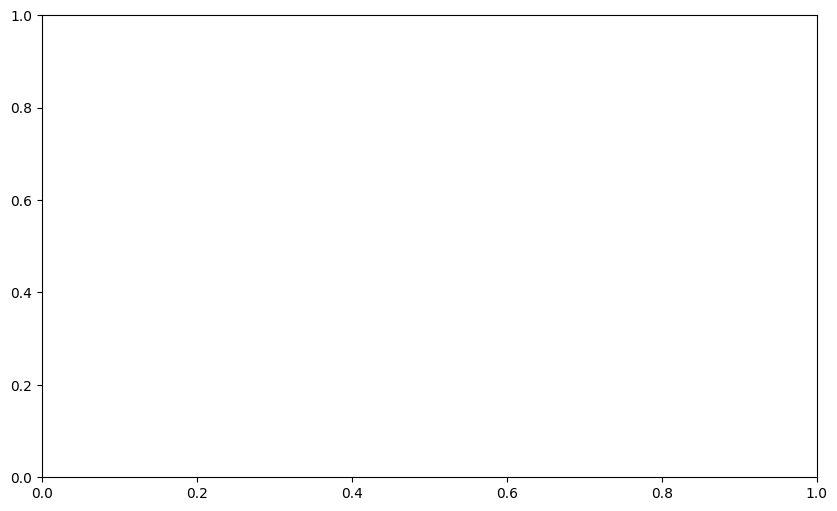

In [ ]:
import seaborn as sns 
from matplotlib import pyplot as plt 
from plotly.colors import qualitative

# fig size
plt.figure(figsize=(15, 6))

# Increase font sizes for axis labels and tick labels
# sns.set_context("notebook", font_scale=1.5)  # font_scale increases all text sizes

dfs = []
for records in [records_ptb_xl, records_cpsc, records_mit_cls, records_mit_r_peaks, records_exe_r, records_sleep_apnea, records_ppg, records_age, lab_test_records]:
    df = pd.DataFrame(records)
    df = df.groupby("group").agg('mean')
    df = df[df.index.isin(ft_groups) | df.index.isin(lp_groups)]
    dfs.append(df)

# for each row on all the dfs sum the runtime
# new dataframe with rows as group
runtime_data = {}
for df in dfs:
    for index, row in df.iterrows():
        if index not in runtime_data.keys():
            print('adding index:', index)
            runtime_data[index] =  0
        # check if runtime is in df
        runtime_data[index] += row['_runtime']

runtime_df = pd.DataFrame.from_dict(runtime_data, orient='index') 
runtime_df = runtime_df.rename(columns={0: 'runtime'})
runtime_df['runtime'] = runtime_df['runtime'] / 3600
colors = [colors_idxs[name] for name in runtime_df.index]

runtime_df_lp = runtime_df[runtime_df.index.isin(lp_groups)]
runtime_df_ft = runtime_df[runtime_df.index.isin(ft_groups)]

colors_ft = [colors_idxs[name][:-2] + '88' for name in runtime_df_ft.index]
colors_lp = [colors_idxs[name][:-2] + 'FF' for name in runtime_df_lp.index]

runtime_df_ft.index = runtime_df_ft.index.map(rename_map_3)
runtime_df_lp.index = runtime_df_lp.index.map(rename_map_3)

runtime_df_ft['colors'] = colors_ft
runtime_df_lp['colors'] = colors_lp

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(runtime_df_ft.index, runtime_df_ft["runtime"], color=runtime_df_ft["colors"])
bars = ax.bar(runtime_df_lp.index, runtime_df_lp["runtime"], color=runtime_df_lp["colors"])

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)
# ax.set_xlabel('Method', fontsize=22)
ax.set_ylabel('Total Runtime (hours)', fontsize=22)
ax.tick_params(axis='y', labelsize=22)
# set max y to + 1
ax.set_ylim(0, runtime_df['runtime'].max() + 5)

# add on top of the bar the number
for i, (ft, lp) in enumerate(zip(runtime_df_ft["runtime"], runtime_df_lp["runtime"])):
    ax.annotate(f"{ft:.1f}({lp:.1f})", 
                (i, max(ft, lp)),  # position above the taller bar
                ha="center", va="bottom", fontsize=18)
    
# annotate supervised
ax.annotate(f'{runtime_df.loc["best_xlstm_sup"]["runtime"]:.1f}', (5, runtime_df.loc["best_xlstm_sup"]["runtime"]), ha='center', va='bottom', fontsize=18)

# save figure
plt.savefig('figs/total_running_time.svg', bbox_inches='tight', dpi=300)

In [ ]:
time_groups = ['time_xlstm_ft', 'time_xlstm_lp', 'time_xlstm_sup', 'time_ecgfm_ft', 'time_ecgfm_lp', 'time_jepa_ft', 'time_jepa_lp', 'time_stmem_ft', 'time_stmem_lp', 'time_trans_ft', 'time_trans_lp']
records_time_ptbxl = get_records("train-ptbxl-diagnosis_superclass-multilabel", metrics=['_runtime'], get_memory=True, pattern=(lambda run: run.group is not None and run.group.startswith("time_")), regex='^time_')
df_time_ptbxl = pd.DataFrame(records_time_ptbxl)
df_time_ptbxl = df_time_ptbxl[df_time_ptbxl['group'].isin(time_groups)]
df_time_ptbxl.head(20)

df_time_ptbxl['memory'] = df_time_ptbxl['memory2'] / (1024 * 1024 * 1024)  # Convert to GB
print(df_time_ptbxl)

100%|██████████| 11/11 [00:04<00:00,  2.70it/s]

             group     _runtime     memory       memory2
0    time_ecgfm_ft   501.421230   4.232300  4.544397e+09
1    time_ecgfm_lp   268.674076   1.538940  1.652425e+09
2     time_jepa_lp  1726.364747   4.802612  5.156766e+09
3     time_jepa_ft  4031.126119  34.130737  3.664760e+10
4    time_stmem_lp  1147.352642   4.177612  4.485677e+09
5    time_stmem_ft  2776.311824  28.435425  3.053230e+10
6    time_trans_lp   232.517489   1.745972  1.874723e+09
7    time_trans_ft   353.886232   4.249878  4.563272e+09
8    time_xlstm_lp   272.991870   2.144409  2.302542e+09
9    time_xlstm_ft   459.003388   4.380737  4.703781e+09
10  time_xlstm_sup   493.882216   4.910034  5.272109e+09


In [ ]:
runtime_ptbxl_df = df_time_ptbxl.rename(columns={'_runtime': 'runtime'})
runtime_ptbxl_df['runtime'] = runtime_ptbxl_df['runtime'] // 60
# set group index
runtime_ptbxl_df = runtime_ptbxl_df.set_index('group')
runtime_ptbxl_df.index = runtime_ptbxl_df.index.str.replace('time_', 'best_')

runtime_ptbxl_df_ft = runtime_ptbxl_df[runtime_ptbxl_df.index.isin(ft_groups)]
runtime_ptbxl_df_lp = runtime_ptbxl_df[runtime_ptbxl_df.index.isin(lp_groups)]

colors = [colors_idxs[name.replace('time_', 'best_')] for name in runtime_ptbxl_df.index]

# Prepare color palettes for FT and LP
colors_ft = [colors_idxs[name][:-2] + '88' for name in runtime_ptbxl_df_ft.index]
colors_lp = [colors_idxs[name][:-2] + 'FF' for name in runtime_ptbxl_df_lp.index]

runtime_ptbxl_df_ft.index = runtime_ptbxl_df_ft.index.map(rename_map_3)
runtime_ptbxl_df_ft['color'] = colors_ft

runtime_ptbxl_df_lp.index = runtime_ptbxl_df_lp.index.map(rename_map_3)
runtime_ptbxl_df_lp['color'] = colors_lp

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(runtime_ptbxl_df_ft.index, runtime_ptbxl_df_ft["runtime"], color=runtime_ptbxl_df_ft["color"])
bars = ax.bar(runtime_ptbxl_df_lp.index, runtime_ptbxl_df_lp["runtime"], color=runtime_ptbxl_df_lp["color"])

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)
# ax.set_xlabel('Method', fontsize=22)
ax.set_ylabel('Total Runtime (minutes)', fontsize=22)
ax.tick_params(axis='both', labelsize=22)
# set max y to + 1
ax.set_ylim(0, runtime_ptbxl_df['runtime'].max() + 5)

# add on top of the bar the number
for i, (ft, lp) in enumerate(zip(runtime_ptbxl_df_ft["runtime"], runtime_ptbxl_df_lp["runtime"])):
    ax.annotate(f"{int(ft)}({int(lp)})", 
                (i, max(ft, lp)),  # position above the taller bar
                ha="center", va="bottom", fontsize=18)
    
# annotate supervised
ax.annotate(f'{int(runtime_ptbxl_df.loc["best_xlstm_sup"]["runtime"])}', (5, runtime_ptbxl_df.loc["best_xlstm_sup"]["runtime"]), ha='center', va='bottom', fontsize=18)

# save figure
plt.savefig('figs/runtime_comparison_ptbxl.svg', bbox_inches='tight', dpi=300)

/tmp/ipykernel_3066449/1621229792.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_3066449/1621229792.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_3066449/1621229792.py:27: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(runtime_ptbxl_df_ft.index, runtime_ptbxl_df_ft["memory"], color=runtime_ptbxl_df_ft["color"])
bars = ax.bar(runtime_ptbxl_df_lp.index, runtime_ptbxl_df_lp["memory"], color=runtime_ptbxl_df_lp["color"])

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=22)
# ax.set_xlabel('Method', fontsize=22)
ax.set_ylabel('Total Memory (GB)', fontsize=22)
ax.tick_params(axis='both', labelsize=22)
# set max y to + 1
ax.set_ylim(0, runtime_ptbxl_df['memory'].max() + 5)

# add on top of the bar the number
for i, (ft, lp) in enumerate(zip(runtime_ptbxl_df_ft["memory"], runtime_ptbxl_df_lp["memory"])):
    ax.annotate(f"{ft:.1f}({lp:.1f})", 
                (i, max(ft, lp)),  # position above the taller bar
                ha="center", va="bottom", fontsize=18)
    
# annotate supervised
ax.annotate(f'{runtime_ptbxl_df.loc["best_xlstm_sup"]["memory"]:.1f}', (5, runtime_ptbxl_df.loc["best_xlstm_sup"]["memory"]), ha='center', va='bottom', fontsize=18)

# save figure
plt.savefig('figs/memory_comparison_ptbxl.svg', bbox_inches='tight', dpi=300)

/tmp/ipykernel_3066449/500086642.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



# RANKING

In [128]:

dfs = []
for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean_age(df) # for age prediction add the mean rsmape
    df = df.groupby("group").agg('mean')
    df = df[df.index.isin(ft_groups) | df.index.isin(lp_groups)]
    dfs.append(df)

In [139]:
categories = ['PTB-XL', 'CPSC2018', 'MIT-BIH', 'Sleep Apnea', 'PPG AF', 'Exercise', 'R-peak', 'Age', 'Blood test', 'Mortality']
categories_metric = ['PTB-XL / AUC', 'CPSC2018 / AUC', 'MIT-BIH / F1', 'Sleep Apnea / AUC', 'PPG / AUC', 'Exercise / F1', 'R-Peaks / F1', 'Age / MAE', 'LAB test / AUC', 'Mortality / CI']
methods = ['ST-MEM', 'ECG-JEPA', 'ECG Founder', 'SimDINOv2\nTransformer', 'xECG', 'xECG\n(code15)', 'Supervised\nxLSTM']

reindex_ft = [4, 5, 3, 6, 0, 1, 2]

def get_full_results(dfs, reindex, is_ft):
    end = 'ft' if is_ft else 'lp'
    data = {
        'PTB-XL / AUC': [   dfs[0].loc[f'best_stmem_{end}']['test_auroc'],
                            dfs[0].loc[f'best_jepa_{end}']['test_auroc'], 
                            dfs[0].loc[f'best_ecgfm_{end}']['test_auroc'], 
                            dfs[0].loc[f'best_trans_{end}']['test_auroc'], 
                            dfs[0].loc[f'best_xlstm_{end}']['test_auroc'],
                            dfs[0].loc[f'best_code15_xlstm_{end}']['test_auroc']],
        'CPSC2018 / AUC': [ dfs[1].loc[f'best_stmem_{end}']['test_auroc'],
                            dfs[1].loc[f'best_jepa_{end}']['test_auroc'], 
                            dfs[1].loc[f'best_ecgfm_{end}']['test_auroc'],
                            dfs[1].loc[f'best_trans_{end}']['test_auroc'],
                            dfs[1].loc[f'best_xlstm_{end}']['test_auroc'],
                            dfs[1].loc[f'best_code15_xlstm_{end}']['test_auroc']],
        'MIT-BIH / F1': [   dfs[2].loc[f'best_stmem_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_jepa_{end}']['test_f1/mean'], 
                            dfs[2].loc[f'best_ecgfm_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_trans_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_xlstm_{end}']['test_f1/mean'],
                            dfs[2].loc[f'best_code15_xlstm_{end}']['test_f1/mean']],
        'Sleep Apnea / AUC': [ dfs[3].loc[f'best_stmem_{end}']['test_auc'],
                            dfs[3].loc[f'best_jepa_{end}']['test_auc'], 
                            dfs[3].loc[f'best_ecgfm_{end}']['test_auc'],
                            dfs[3].loc[f'best_trans_{end}']['test_auc'],
                            dfs[3].loc[f'best_xlstm_{end}']['test_auc'],
                            dfs[3].loc[f'best_code15_xlstm_{end}']['test_auc']],
        'PPG / AUC': [      dfs[4].loc[f'best_stmem_{end}']['test_auroc'],
                            dfs[4].loc[f'best_jepa_{end}']['test_auroc'], 
                            dfs[4].loc[f'best_ecgfm_{end}']['test_auroc'],
                            dfs[4].loc[f'best_trans_{end}']['test_auroc'],
                            dfs[4].loc[f'best_xlstm_{end}']['test_auroc'],
                            dfs[4].loc[f'best_code15_xlstm_{end}']['test_auroc']],
        'Exercise / F1': [  dfs[5].loc[f'best_stmem_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_jepa_{end}']['test_f1_20'], 
                            dfs[5].loc[f'best_ecgfm_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_trans_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_xlstm_{end}']['test_f1_20'],
                            dfs[5].loc[f'best_code15_xlstm_{end}']['test_f1_20']],
        'R-Peaks / F1': [  dfs[6].loc[f'best_stmem_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_jepa_{end}']['test_f1_20'], 
                            dfs[6].loc[f'best_ecgfm_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_trans_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_xlstm_{end}']['test_f1_20'],
                            dfs[6].loc[f'best_code15_xlstm_{end}']['test_f1_20']],
        'Age / MAE': [      1 - dfs[7].loc[f'best_stmem_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_jepa_{end}']['mean_rsmape'], 
                            1 - dfs[7].loc[f'best_ecgfm_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_trans_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_xlstm_{end}']['mean_rsmape'],
                            1 - dfs[7].loc[f'best_code15_xlstm_{end}']['mean_rsmape']],
        'LAB test / AUC': [ dfs[8].loc[f'best_stmem_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_jepa_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_ecgfm_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_trans_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_xlstm_{end}']['test_auroc_avg'],
                            dfs[8].loc[f'best_code15_xlstm_{end}']['test_auroc_avg']],
        'Mortality / CI': [ dfs[9].loc[f'best_stmem_{end}']['test_ci'],
                            dfs[9].loc[f'best_jepa_{end}']['test_ci'],
                            dfs[9].loc[f'best_ecgfm_{end}']['test_ci'],
                            dfs[9].loc[f'best_trans_{end}']['test_ci'],
                            dfs[9].loc[f'best_xlstm_{end}']['test_ci'],
                            dfs[9].loc[f'best_code15_xlstm_{end}']['test_ci']],
    }# RANKING

    if is_ft:
        data['PTB-XL / AUC'].append(dfs[0].loc[f'best_xlstm_sup']['test_auroc'])
        data['CPSC2018 / AUC'].append(dfs[1].loc[f'best_xlstm_sup']['test_auroc'])
        data['MIT-BIH / F1'].append(dfs[2].loc[f'best_xlstm_sup']['test_f1/mean'])
        data['Sleep Apnea / AUC'].append(dfs[3].loc[f'best_xlstm_sup']['test_auc'])
        data['PPG / AUC'].append(dfs[4].loc[f'best_xlstm_sup']['test_auroc'])
        data['Exercise / F1'].append(dfs[5].loc[f'best_xlstm_sup']['test_f1_20'])
        data['R-Peaks / F1'].append(dfs[6].loc[f'best_xlstm_sup']['test_f1_20'])
        data['Age / MAE'].append(1 - dfs[7].loc[f'best_xlstm_sup']['mean_rsmape'])
        data['LAB test / AUC'].append(dfs[8].loc[f'best_xlstm_sup']['test_auroc_avg'])
        data['Mortality / CI'].append(dfs[9].loc[f'best_xlstm_sup']['test_ci'])
        data['Sleep Apnea / AUC'][4] = dfs[3].loc[f'best_xlstm_ft']['test_auc']

    if reindex is not None:
        df = pd.DataFrame(data, index=methods if is_ft else methods[:-1])
        df = df.reindex(df.index[reindex])
    else:
        df = pd.DataFrame(data)
        
    return df

df_raw = get_full_results(dfs, reindex_ft, is_ft=True)
df_raw.head(n=10)


,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI
xECG,0.927636,0.981308,0.677293,0.927839,0.883472,0.968441,0.920580,0.927282,0.747493,0.710135
xECG\n(code15),0.920755,0.976973,0.481287,0.874788,0.875427,0.963732,0.803164,0.923635,0.733019,0.693982
SimDINOv2\nTransformer,0.924652,0.965467,0.425415,0.680796,0.779656,0.632738,0.900353,0.916827,0.725261,0.700722
Supervised\nxLSTM,0.890728,0.951107,0.402199,0.834288,0.876326,0.965772,0.889045,0.921501,0.683108,0.622827
ST-MEM,0.929916,0.958217,0.644152,0.700258,0.642692,0.985623,0.937266,0.932062,0.744403,0.694407
ECG-JEPA,0.923336,0.965220,0.583076,0.690438,0.817771,0.858583,0.909293,0.927172,0.735094,0.705418
ECG Founder,0.930447,0.969354,0.207231,0.778393,0.845594,0.082417,0.011331,0.924954,0.714474,0.688047


In [141]:
reindex_lp = [4, 5, 3, 0, 1, 2]
df_lp_raw = get_full_results(dfs, reindex_lp, is_ft=False)
df_lp_raw

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI
xECG,0.915361,0.967798,0.673956,0.879130,0.750782,0.891641,0.589917,0.923302,0.732535,0.703769
xECG\n(code15),0.909255,0.963848,0.448105,0.796271,0.714632,0.933412,0.657674,0.918443,0.714512,0.692093
SimDINOv2\nTransformer,0.913967,0.950829,0.395488,0.644381,0.655769,0.301037,0.476394,0.911832,0.724285,0.695453
ST-MEM,0.867034,0.922097,0.436191,0.598744,0.653246,0.627345,0.564153,0.902894,0.708151,0.697553
ECG-JEPA,0.902226,0.961038,0.496206,0.666892,0.476940,0.526109,0.444294,0.919359,0.721784,0.705941
ECG Founder,0.917335,0.961727,0.206484,0.776873,0.640672,0.083204,0.010323,0.922752,0.711333,0.682931


In [142]:
# add color to each method for consistency
from plotly.colors import qualitative

colors = qualitative.Plotly[:len(df_raw)]
df_raw["color"] = [colors[idx] for idx in reindex_ft]
df_lp_raw["color"] = [colors[idx] for idx in reindex_lp]

# add some alpha for better visibility
pastel_colors = [f"{color}C0" for color in colors]  #
df_raw["pastel_color"] = [pastel_colors[idx] for idx in reindex_ft]
df_lp_raw["pastel_color"] = [pastel_colors[idx] for idx in reindex_lp]

df_raw.head(n=100)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,PPG / AUC,Exercise / F1,R-Peaks / F1,Age / MAE,LAB test / AUC,Mortality / CI,color,pastel_color
xECG,0.927636,0.981308,0.677293,0.927839,0.883472,0.968441,0.920580,0.927282,0.747493,0.710135,#FFA15A,#FFA15AC0
xECG\n(code15),0.920755,0.976973,0.481287,0.874788,0.875427,0.963732,0.803164,0.923635,0.733019,0.693982,#19D3F3,#19D3F3C0
SimDINOv2\nTransformer,0.924652,0.965467,0.425415,0.680796,0.779656,0.632738,0.900353,0.916827,0.725261,0.700722,#AB63FA,#AB63FAC0
Supervised\nxLSTM,0.890728,0.951107,0.402199,0.834288,0.876326,0.965772,0.889045,0.921501,0.683108,0.622827,#FF6692,#FF6692C0
ST-MEM,0.929916,0.958217,0.644152,0.700258,0.642692,0.985623,0.937266,0.932062,0.744403,0.694407,#636EFA,#636EFAC0
ECG-JEPA,0.923336,0.965220,0.583076,0.690438,0.817771,0.858583,0.909293,0.927172,0.735094,0.705418,#EF553B,#EF553BC0
ECG Founder,0.930447,0.969354,0.207231,0.778393,0.845594,0.082417,0.011331,0.924954,0.714474,0.688047,#00CC96,#00CC96C0


In [147]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import plotly.io as pio

pio.templates.default = "plotly"  # Set default template to white background
import numpy as np

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

min_v = 0. # df_raw.min().min()
max_v = 1.# df_raw.max().max()
print(f"Min value: {min_v}, Max value: {max_v}")

num_methods = len(df_raw)
rows = 2
cols = 4
fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}],
           [{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=df_raw.index.tolist(),
    vertical_spacing=0.1,  # Add vertical spacing between subplots
    horizontal_spacing=0.2  # Add horizontal spacing between subplots
)

gap = 1.0 / num_methods
padding = 0.06

for i, (idx, row) in enumerate(df_raw.iterrows()):

    current_row = (i // cols) + 1
    current_col = (i % cols) + 1
    #if i == len(df_z_scaled) -1:
    #    continue
    values = row.tolist()[:-2] + [row.tolist()[0]]  # close the loop
    print(values)
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=2, color=row['color']),
            hoverinfo='skip',
            marker=dict(
                symbol="diamond",   # <-- change marker shape here
                size=8,            # marker size
                color=row['color']  # marker color
            ),
        ),
        row=current_row, col=current_col
    )

    if i != 2:
        idx = i if i < 2 else i-1
        values = df_lp_raw.iloc[idx].tolist()[:-2] + [df_lp_raw.iloc[idx].tolist()[0]]  # close the loop
        values = [float(value) for value in values]
        print(values)
        fig.add_trace(
            go.Scatterpolar(
                r=values,
                theta=categories_closed,
                fill='toself',
                name=idx,
                line=dict(width=2, color=row['color']),
                hoverinfo='skip',
                marker=dict(
                    symbol="circle",   # <-- change marker shape here
                    size=8,            # marker size
                    color=row['color']  # marker color
                ),
            ),
            row=current_row, 
            col=current_col
        )

    # Update polar layout for each subplot
    fig.update_layout({
        f'polar{i+1}': dict(
            angularaxis=dict(rotation=30),  # keep your rotation
            radialaxis=dict(
                visible=True, 
                range=[min_v, max_v], 
                showticklabels=True, 
                showline=True,
                showgrid=True,
                angle=102,
                ticks="outside",
                tickcolor="white",
                linecolor='white',
                ticklen=4,
                tickangle=102,
                # tickvals=[0, 0.3, 0.7, 1],        # positions on the axis
                # ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1"],  # what to display
                tickvals=[0, 0.2, 0.4, 0.6, 0.8, 1],        # positions on the axis
                ticktext=["0", "0.2", "0.4", "0.6", "0.8", "1"],  # what to display
                tickfont=dict(
                    size=10,       # font size of tick labels
                ),
            )
        )
    })


# Optional: adjust overall layout for better spacing
fig.update_layout(
    # width=25,   # 88mm in pixels (88mm * 2.835 pixels/mm)
    # height=200,   # Maintain aspect ratio (2:3 -> height = width * 2/3)
    font=dict(family="Arial", size=12),  # Sans-serif font, 6pt (between 5-7pt range)
    showlegend=False,  # Hide legend since each subplot is labeled
    margin=dict(l=60, r=60, t=20, b=20), # Tight margins for Nature format
    # padding=dict(t=10, b=10, l=10, r=10)
)

fig.update_annotations(
    font=dict(size=14, family="Arial"),
    showarrow=False,
    #yshift=5,  # Adjust vertical position of titles
)


# fig.tight_layout()
# save pdf
# plt.savefig("figs/radar_chart_methods.svg", bbox_inches='tight')
fig.write_image("figs/radar_chart_methods.svg", width=900, height=500)
# fig.show()

Min value: 0.0, Max value: 1.0
[0.9276357054710388, 0.9813077569007873, 0.6772925734519959, 0.9278392195701599, 0.8834720611572265, 0.9684410333633423, 0.9205804228782654, 0.9272821853558222, 0.7474927425384521, 0.7101354241371155, 0.9276357054710388]
[0.9153610706329346, 0.9677982926368713, 0.6739564895629883, 0.8791297197341919, 0.7507818222045899, 0.8916414499282836, 0.589917266368866, 0.9233024472991626, 0.7325353741645813, 0.7037688374519349, 0.9153610706329346]
[0.9207549095153809, 0.9769729495048523, 0.48128690123558043, 0.874788236618042, 0.8754271149635315, 0.9637316703796387, 0.8031643390655517, 0.923634622991085, 0.7330185532569885, 0.6939819931983948, 0.9207549095153809]
[0.9092548966407776, 0.9638484835624694, 0.4481050431728363, 0.7962714552879333, 0.7146319031715394, 0.9334120631217957, 0.6576740503311157, 0.9184432476758957, 0.7145117521286011, 0.6920934796333313, 0.9092548966407776]
[0.9246517300605774, 0.9654669046401978, 0.425414901971817, 0.68079594373703, 0.7796563

In [148]:
df_raw_score = df_raw.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)
df_raw_score_lp = df_lp_raw.copy().drop(['pastel_color', 'color'], axis=1).mean(axis=1)

df_raw_score = df_raw_score.to_frame(name='raw_score')
df_raw_score_lp = df_raw_score_lp.to_frame(name='raw_score_lp')

df = df_raw_score.merge(df_raw_score_lp, left_index=True, right_index=True, how='left')
df['pastel_color'] = df_raw['pastel_color']
df = df.sort_values(by='raw_score', ascending=False)
df

,raw_score,raw_score_lp,pastel_color
xECG,0.867148,0.802819,#FFA15AC0
xECG\n(code15),0.824676,0.774825,#19D3F3C0
ST-MEM,0.816899,0.697741,#636EFAC0
ECG-JEPA,0.811540,0.682079,#EF553BC0
Supervised\nxLSTM,0.803690,NaN,#FF6692C0
SimDINOv2\nTransformer,0.765189,0.666944,#AB63FAC0
ECG Founder,0.615224,0.591364,#00CC96C0


/tmp/ipykernel_1818895/2368409457.py:13: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_1818895/2368409457.py:14: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



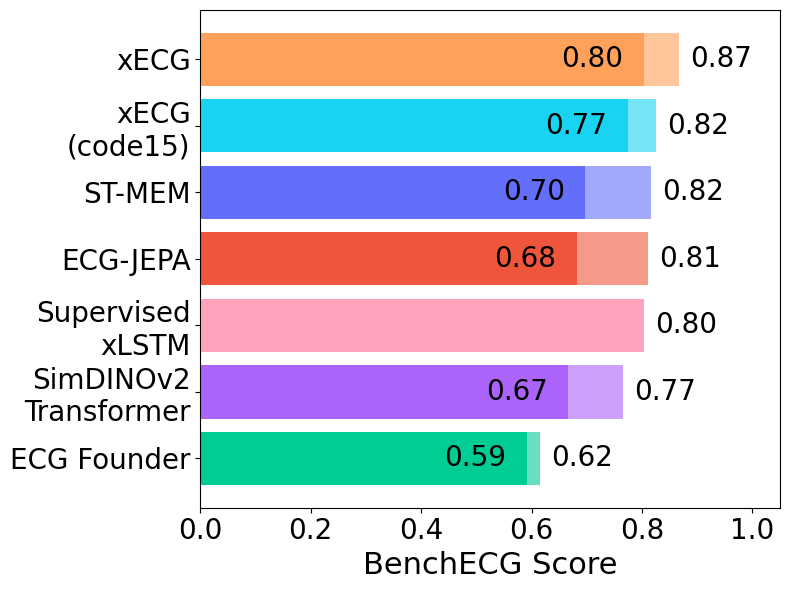

In [150]:
# plot combined bench score on index
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(df.index, df["raw_score_lp"], color=df["pastel_color"].str[:-2] + 'FF')
bars = ax.barh(df.index, df["raw_score"], color=df["pastel_color"].str[:-2] + '99')

# sns.set_style("white")
# 
# 
# _context("poster")

ax.set_yticklabels(df.index, fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)

# Add labels to bars
for i, (value, label) in enumerate(zip(df["raw_score"], df.index)):
    ax.text(value + 0.02, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

# Add labels to bars
for i, (value, label) in enumerate(zip(df["raw_score_lp"], df.index)):
    if value:
        ax.text(value - 0.15, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')


ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])                  # positions of the ticks
ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

ax.set_xlabel('BenchECG Score', fontsize=22)
#ax.set_ylabel('Method', fontsize=12)
# ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
ax.invert_yaxis()  # Highest rank at top
ax.set_xlim([0, 1.05])  # Adjust x-axis limit

plt.tight_layout()
plt.savefig("figs/bench_ecg_scores.svg", dpi=300)


In [151]:
reference_metrics = ['test_auroc', 'test_auroc', 'test_f1/mean', 'test_auc', 'test_auroc', 'test_f1_20', 'test_f1_20', 'mean_rsmape', 'test_auroc_avg', 'test_ci']
record_list = [records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]
def get_dfs_list(group):
    dfs_full = []
    for i, records in enumerate(record_list):
        df = pd.DataFrame(records)
        if i == 7: 
            df = add_mean_age(df) # for age prediction add the mean rsmape
            df[reference_metrics[i]] =  1 - df[reference_metrics[i]]
        # df = df.groupby("group").agg('mean')
        df = df[df['group'].isin(group)]
        df = df[['group', reference_metrics[i]]]
        df = df.rename(columns={reference_metrics[i]: 'reference_metric'})
        # make group index
        df = df.set_index('group')
        dfs_full.append(df)
    return dfs_full

full_runs_ft = get_dfs_list(ft_groups)
full_runs_lp = get_dfs_list(lp_groups)

In [ ]:
import pandas as pd

def get_rank(df, metric, mode='max', alpha=0.05):
    """
    Assigns ranks to groups based on their metric values with t-test based ties.

    Parameters
    ----------
    df : pd.DataFrame
        Multi-indexed dataframe where level 0 is group and rows are runs.
    metric : str
        Column name with the metric to compare.
    mode : str, 'max' or 'min'
        Whether higher or lower values are better.
    alpha : float
        Significance threshold for the t-test.

    Returns
    -------
    pd.DataFrame
        DataFrame with group, mean, and assigned rank (competition style).
    """

    groups = df.index.unique()
    means = df.groupby(level=0)[metric].mean()

    # sort groups by mean
    if mode == 'max':
        means = means.sort_values(ascending=False)
    else:
        means = means.sort_values(ascending=True)

    # pairwise p-values
    pvals = pd.DataFrame(index=groups, columns=groups, dtype=float)
    for g1 in groups:
        for g2 in groups:
            if g1 == g2:
                pvals.loc[g1, g2] = 1.0
            else:
                s1 = df.loc[g1, metric]
                s2 = df.loc[g2, metric]
                _, p = mannwhitneyu(s1, s2, alternative='two-sided')
                pvals.loc[g1, g2] = p

    # assign ranks
    ranks = {}
    current_rank = 1
    i = 0
    sorted_groups = means.index.tolist()

    while i < len(sorted_groups):
        g = sorted_groups[i]
        # group of equivalent methods (by t-test)
        group = [g]
        j = i + 1
        while j < len(sorted_groups):
            g2 = sorted_groups[j]
            if pvals.loc[g, g2] > alpha:
                group.append(g2)
                j += 1
            else:
                break
        for gg in group:
            ranks[gg] = current_rank
        current_rank += len(group)
        i = j

    result = pd.DataFrame({
        "group": means.index,
        "mean": means.values,
        "rank": [ranks[g] for g in means.index]
    })

    return result

In [153]:
full_runs_ft_ranked = [get_rank(task, 'reference_metric') for task in full_runs_ft]
full_runs_lp_ranked = [get_rank(task, 'reference_metric') for task in full_runs_lp]

print(full_runs_lp_ranked[0])

print([e.loc[e.group == "best_xlstm_lp"] for e in full_runs_lp_ranked])

                  group      mean  rank
0         best_ecgfm_lp  0.917335     1
1         best_xlstm_lp  0.915361     2
2         best_trans_lp  0.913967     3
3  best_code15_xlstm_lp  0.909255     4
4          best_jepa_lp  0.902226     5
5         best_stmem_lp  0.867034     6
[           group      mean  rank
1  best_xlstm_lp  0.915361     2,            group      mean  rank
0  best_xlstm_lp  0.967798     1,            group      mean  rank
0  best_xlstm_lp  0.673956     1,            group     mean  rank
0  best_xlstm_lp  0.87913     1,            group      mean  rank
0  best_xlstm_lp  0.750782     1,            group      mean  rank
1  best_xlstm_lp  0.891641     2,            group      mean  rank
1  best_xlstm_lp  0.589917     2,            group      mean  rank
0  best_xlstm_lp  0.923302     1,            group      mean  rank
0  best_xlstm_lp  0.732535     1,            group      mean  rank
1  best_xlstm_lp  0.703769     2]


In [154]:
# concatenate
full_runs_ft_ranked_cat = pd.concat(full_runs_ft_ranked).groupby('group').agg({'mean': 'mean', 'rank': 'mean'}).sort_values(by='rank')
full_runs_lp_ranked_cat = pd.concat(full_runs_lp_ranked).groupby('group').agg({'mean': 'mean', 'rank': 'mean'}).sort_values(by='rank')


# concatenate pastel colors
full_runs_ft_ranked_cat['pastel_color'] = full_runs_ft_ranked_cat.index.map(colors_idxs)
full_runs_lp_ranked_cat['pastel_color'] = full_runs_lp_ranked_cat.index.map(colors_idxs)

# map index to method
full_runs_ft_ranked_cat.index = full_runs_ft_ranked_cat.index.map(rename_map_3)
full_runs_lp_ranked_cat.index = full_runs_lp_ranked_cat.index.map(rename_map_3)

print(full_runs_ft_ranked_cat)
print(full_runs_lp_ranked_cat)

                            mean  rank pastel_color
group                                              
xECG                    0.867148   1.5    #FFA15AC0
ST-MEM                  0.816899   3.0    #636EFAC0
NaN                     0.824676   3.7    #FF6692C0
ECG-JEPA                0.811540   3.8    #EF553BC0
ECGFounder              0.615224   4.6    #00CC96C0
SimDINOv2\nTransformer  0.765189   4.7    #AB63FAC0
Supervised\nxLSTM       0.803690   5.0    #19D3F3C0
                            mean  rank pastel_color
group                                              
xECG                    0.802819   1.4    #FFA15AC0
NaN                     0.774825   2.8    #FF6692C0
ECG-JEPA                0.682079   3.7    #EF553BC0
ECGFounder              0.591364   4.0    #00CC96C0
SimDINOv2\nTransformer  0.666944   4.0    #AB63FAC0
ST-MEM                  0.697741   4.5    #636EFAC0


TypeError: 'value' must be an instance of str or bytes, not a float

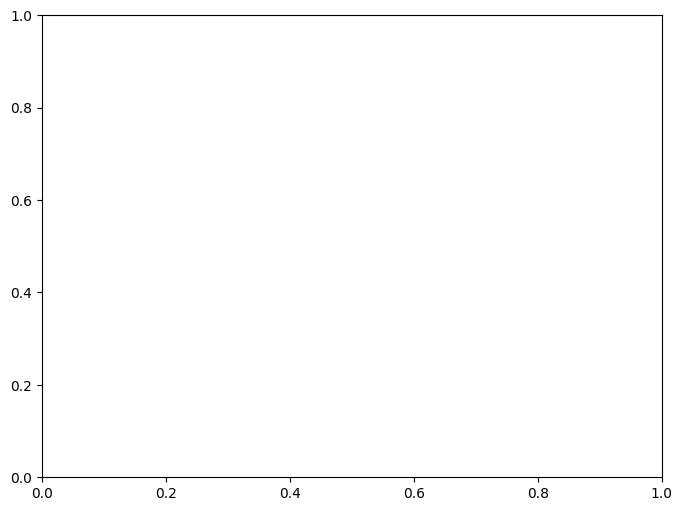

In [155]:
import matplotlib.pyplot as plt

def plot_bench_rank(df, name='mean_rank_methods.png', title=''):
    df_ranked_sorted = df.copy().drop(columns=["pastel_color"])
    df_ranked_sorted = df_ranked_sorted.sort_values(by="rank", ascending=True)

    df_ranked_sorted["pastel_color"] = df["pastel_color"]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["rank"], color=df_ranked_sorted["pastel_color"].str[:-2] + 'FF')
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["rank"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')
    
    ax.set_xticks([0, 1, 2, 3, 4, 5])                  # positions of the ticks
    ax.set_xticklabels([0, 1, 2, 3, 4, 5], fontsize=20)

    # Format plo
    ax.set_xlabel(title, fontsize=22)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["rank"].max() + 0.7])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_rank(full_runs_ft_ranked_cat, "figs/mean_rank_methods.svg", title='Mean rank (finetuning)')
plot_bench_rank(full_runs_lp_ranked_cat, "figs/mean_rank_methods_lp.svg", title='Mean rank (linear probing)')

In [ ]:
dfs_bench_score_ft = []

def get_metric_by_task(task):
    if task == categories[0] or task == categories[1] or task == categories[4]: # ptbxl or cpsc ppg
        return 'test_auroc'
    if task == categories[2]: # mit-bih
        return 'test_f1/mean'
    if task == categories[3]: # sleep apnea
        return 'test_auc'
    if task == categories[5] or task == categories[6]: # exe and rpeak
        return 'test_f1_20'
    if task == categories[7]: # age
        return 'mean_rsmape'
    if task == categories[8]: # lab
        return 'test_auroc_avg'
    if task == categories[9]: # mortality
        return 'test_ci'

for i, records in enumerate([records_ptb_xl, records_cpsc, records_mit_cls, records_sleep_apnea, records_ppg, records_exe_r, records_mit_r_peaks, records_age, lab_test_records, mortality_test_records]):
    df = pd.DataFrame(records)
    if i == 7: df = add_mean_age(df) # for age prediction add the mean rsmape
    # df = df.groupby("group").agg('mean')
    df = df[df['group'].isin(ft_groups) | df['group'].isin(lp_groups)]
    df['task'] = categories[i]
    if i == 7:
        df['task_score'] = 1 - df[get_metric_by_task(categories[i])]
    else:
        df['task_score'] = df[get_metric_by_task(categories[i])]
    dfs_bench_score_ft.append(df)



df_bench_score = pd.concat(dfs_bench_score_ft)
df_bench_score_ft = df_bench_score[df_bench_score['group'].isin(ft_groups)]
df_bench_score_lp = df_bench_score[df_bench_score['group'].isin(lp_groups)]

print(df_bench_score_ft[(df_bench_score_ft['group'] == 'best_xlstm_ft') & (df_bench_score_ft['task'] == 'Mortality')])


            group  test_acc  test_f1  test_auroc  test_auprc     _runtime  \
35  best_xlstm_ft       NaN      NaN         NaN         NaN  2994.325083   
36  best_xlstm_ft       NaN      NaN         NaN         NaN  3513.353563   
37  best_xlstm_ft       NaN      NaN         NaN         NaN  2736.758589   
38  best_xlstm_ft       NaN      NaN         NaN         NaN  3248.958460   
39  best_xlstm_ft       NaN      NaN         NaN         NaN  2867.877244   

         task  task_score  test_sensitivity/mean  test_ppv/mean  ...  \
35  Mortality    0.713503                    NaN            NaN  ...   
36  Mortality    0.708657                    NaN            NaN  ...   
37  Mortality    0.711226                    NaN            NaN  ...   
38  Mortality    0.708137                    NaN            NaN  ...   
39  Mortality    0.709155                    NaN            NaN  ...   

    valid_rsmape_0  mean_mae  mean_rsmape  val_test_diff_mae  test_auroc_avg  \
35             NaN      

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.colors import qualitative
from matplotlib.ticker import MultipleLocator

def plot_bench_score(df, name='mean_score_methods.png'):
    df = df[['task', 'task_score', 'group']].copy()

    # Step 1: add run index inside each (task, group)
    df["pos"] = df.groupby(["task", "group"]).cumcount()
    # df = df[df["pos"] < 5]

    # Step 2: average across tasks, for each (group, pos)
    per_pos = (
        df.groupby(["group", "pos"])["task_score"]
        .mean()
        .reset_index()
    )

    # print(per_pos)

    # Step 3: now aggregate across positions -> mean of means, std of means
    summary = (
        per_pos.groupby("group")["task_score"]
        .agg(mean_over_runs="mean", std_over_runs="std")
        .reset_index()
    )

    # add the color column back for plotting
    summary["pastel_color"] = pastel_colors[:len(summary)]
    summary.index = methods[:len(summary)]

    summary = summary.sort_values(by="mean_over_runs", ascending=False)

    print(summary[['group', 'mean_over_runs', 'std_over_runs']])



    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw horizontal bars
    bars = ax.barh(summary.index, summary["mean_over_runs"], color=summary["pastel_color"])
    # add std line
    ax.errorbar(summary["mean_over_runs"], summary.index, xerr=summary["std_over_runs"], fmt='none', c='black', capsize=2)

    ax.set_yticklabels(summary.index, fontsize=20)
    ax.set_xticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=20)

    # Add labels to bars
    for i, (value, std, label) in enumerate(zip(summary["mean_over_runs"], summary["std_over_runs"], summary.index)):
        ax.text(value + std + 0.02, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

    # Format plot
    ax.set_xlabel('BenchECG Score', fontsize=22)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, summary["mean_over_runs"].max() + 0.2])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_score(df_bench_score_ft, name='figs/mean_score_methods.svg')
plot_bench_score(df_bench_score_lp, name='figs/mean_score_methods_lp.svg')

                                 group  mean_over_runs  std_over_runs
xECG                     best_xlstm_ft        0.867148       0.003728
ECG Founder              best_stmem_ft        0.819644       0.007991
ECG-JEPA                  best_jepa_ft        0.816078       0.014707
Supervised\nxLSTM       best_xlstm_sup        0.811799       0.012691
SimDINOv2\nTransformer   best_trans_ft        0.766558       0.005441
ST-MEM                   best_ecgfm_ft        0.613562       0.008859
                                group  mean_over_runs  std_over_runs
xECG                    best_xlstm_lp        0.802819       0.002591
ECG Founder             best_stmem_lp        0.697847       0.003668
SimDINOv2\nTransformer  best_trans_lp        0.666271       0.005246
ST-MEM                  best_ecgfm_lp        0.589285       0.008235
ECG-JEPA                 best_jepa_lp        0.579199       0.107889


/tmp/ipykernel_3066449/2766620671.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3066449/2766620671.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3066449/2766620671.py:48: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_3066449/2766620671.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

